### TokaMaker Example: Equilibrium reconstruction in DIII-D with Scape-Off Layer Current {#doc_tMaker_DIIID_ex4}
==========
In this example we show how to perform an equilibrium reconstruction in DIII-D using real data from a gEQDSK file, a k-file and a MHDIn.dat file. We also utilize the scrape-off layer functionality to model current outside the LCFS.

**Warning:** The reconstruction functionality in TokaMaker is still a work in progress, as the PSI-Tri capabilities are activated and tested. Please use with care.

In [1]:
import os
import sys
import json
import random
from collections import OrderedDict
import numpy as np
import matplotlib.pyplot as plt
plt.rcParams['figure.figsize']=(6,6)
plt.rcParams['font.weight']='bold'
plt.rcParams['axes.labelweight']='bold'
plt.rcParams['lines.linewidth']=2
plt.rcParams['lines.markeredgewidth']=2
%matplotlib inline
%config InlineBackend.figure_format = "retina"

## Load TokaMaker library

To load the TokaMaker python module we need to tell python where to the module is located. This can be done either through the `PYTHONPATH` environment variable or using within a script using `sys.path.append()` as below, where we look for the environement variable `OFT_ROOTPATH` to provide the path to where the OpenFUSIONToolkit is installed (`/Applications/OFT` on macOS).

For meshing we will use the \ref OpenFUSIONToolkit.TokaMaker.gs_Domain "gs_Domain" class to build a 2D triangular grid suitable for Grad-Shafranov equilibria. This class uses the [triangle code](https://www.cs.cmu.edu/~quake/triangle.html) through a [python wrapper](https://pypi.org/project/triangle/).

In [2]:
tokamaker_python_path = os.getenv('OFT_ROOTPATH')
if tokamaker_python_path is not None:
    sys.path.append(os.path.join(tokamaker_python_path,'python'))
from OpenFUSIONToolkit import OFT_env
from OpenFUSIONToolkit.TokaMaker import TokaMaker
from OpenFUSIONToolkit.TokaMaker.meshing import gs_Domain
from OpenFUSIONToolkit.TokaMaker.reconstruction import reconstruction
from OpenFUSIONToolkit.TokaMaker.util import read_eqdsk, read_mhdin, read_kfile

## Initialize TokaMaker object
We now create a \ref OpenFUSIONToolkit.OFT_env "OFT_env" instance for execution using two threads and a \ref OpenFUSIONToolkit.TokaMaker.TokaMaker "TokaMaker" instance to use for equilibrium calculations. Note at present only a single `TokaMaker` instance can be used per python kernel, so this command should only be called **once** in a given Jupyter notebook or python script. In the future this restriction may be relaxed.

In [3]:
myOFT = OFT_env(nthreads=2)
mygs = TokaMaker(myOFT)

#----------------------------------------------
Open FUSION Toolkit Initialized


python(19358) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
python(19359) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
python(19360) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
python(19361) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.


Development branch:    Add-FSOL
Revision id:           dccdae47
Parallelization Info:
  Not compiled with MPI
  # of OpenMP threads =    2
Integer Precisions    =    4   8
Float Precisions      =    4   8  16
Complex Precisions    =    4   8
LA backend            = native
#----------------------------------------------



## Load Info from gEQDSK File and MHDIn.Dat


In [4]:
shot_tag = '199087.04300'

eqdsk = read_eqdsk('DIIID_files/g'+shot_tag)

e_coil_names = ['ECOILA','ECOILB','E567UP','E567DN','E89DN','E89UP']
f_coil_names = ['F1A', 'F2A', 'F3A', 'F4A', 'F5A', 'F6A', 'F7A', 'F8A', 'F9A', 'F1B', 'F2B', 'F3B', 'F4B', 'F5B', 'F6B', 'F7B', 'F8B', 'F9B']

machine_dict, _ = read_mhdin('DIIID_files/mhdin040324.dat', e_coil_names, f_coil_names)

## Build Mesh in TokaMaker
Now we build and setup a mesh using DIII-D geometry from a given JSON file and MHDIn.dat. Then, we call \ref OpenFUSIONToolkit.TokaMaker.TokaMaker.setup "setup()" to setup the required solver objects. During this call we can specify the desired element order (min=2, max=4) and the toroidal field through F0 = B0*R0, where B0 is the toroidal field at a reference location R0. These values come from the gEQDSK file.

In [ ]:
plasma_dx = 0.04
coil_dx = 0.03
vv_dx = 0.04
vac_dx = 0.10

with open('DIIID_files/DIIID_geom.json','r') as fid:
    DIIID_geom = json.load(fid)

# Create a G-S domain
gs_mesh = gs_Domain()
# Define region information for mesh
gs_mesh.define_region('air',vac_dx,'boundary')                     # Define the bounding region
gs_mesh.define_region('plasma',plasma_dx,'plasma')                 # Define the plasma region and resolution
gs_mesh.define_region('vacuum',vv_dx,'vacuum',allow_xpoints=True)  # Define the vacuum inside the VV
# Define regions for VV
for i, vv_segment in enumerate(DIIID_geom["vv"]):
    gs_mesh.define_region('vv{0}'.format(i),vv_dx,'conductor',eta=vv_segment[1])

# Define geometry
gs_mesh.add_polygon(DIIID_geom['limiter'],'plasma',parent_name='vacuum')  # Define the shape of the limiter
gs_mesh.add_enclosed([1.75,1.25],'vacuum')
# Define regions for VV
for i, vv_segment in enumerate(DIIID_geom["vv"]):
    gs_mesh.add_polygon(vv_segment[0],'vv{0}'.format(i),parent_name='air')

### Load E and F Coils from MHDIn.Dat

In [6]:
# Define F coils
for key, coil in DIIID_geom["coils"].items():
    if key.startswith('ECOIL'):
        continue
    gs_mesh.define_region(key,coil_dx,'coil',nTurns=machine_dict['FCOIL'][key][4])
    gs_mesh.add_polygon(coil["pts"],key,parent_name='air')

# Define E Coils
for coil_set_name, coil_set in machine_dict['ECOIL'].items():
    i = 0
    for coil in coil_set:
        coil_name = "{}_{}".format(coil_set_name, i)
        i = i + 1
        r, z, w, h = coil
        gs_mesh.define_region(coil_name,coil_dx,'coil',coil_set=coil_set_name,nTurns=1) # Check nTurns
        gs_mesh.add_rectangle(r, z, w, h, coil_name, parent_name='air')


### Plot Topology

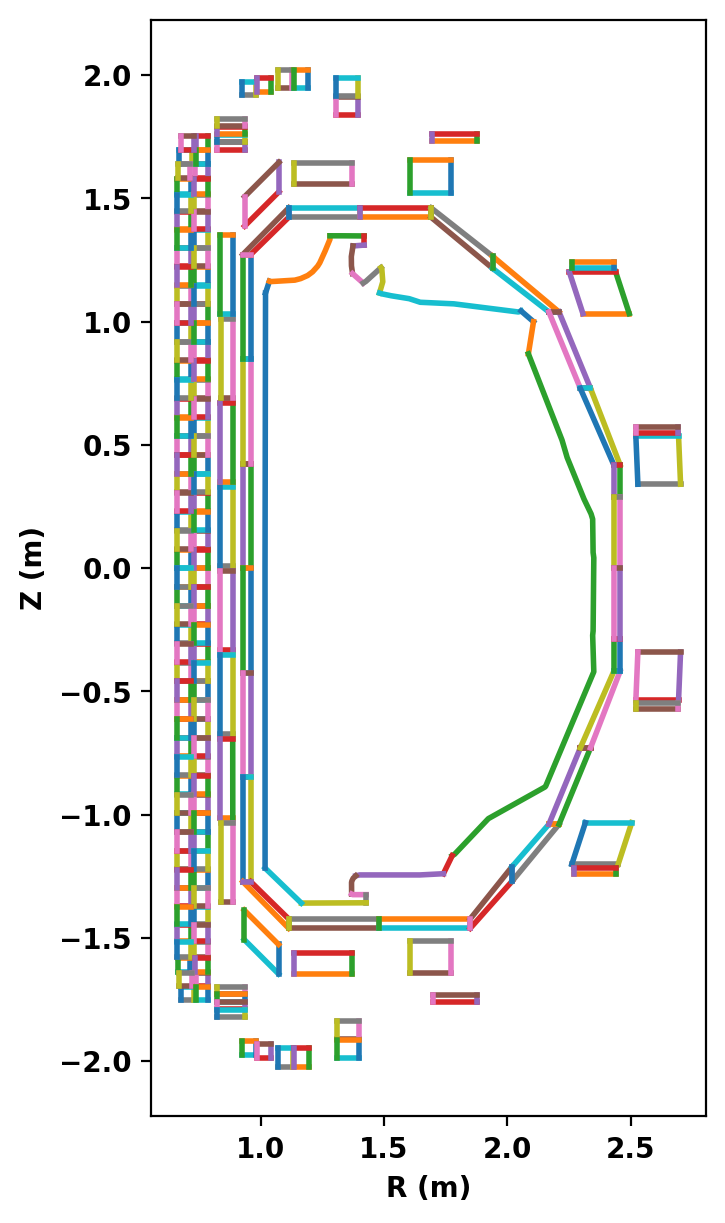

In [7]:
fig, ax = plt.subplots(1,1,figsize=(4,6),constrained_layout=True)
gs_mesh.plot_topology(fig,ax)

plt.show()

### Setup Mesh

In [8]:
mesh_pts, mesh_lc, mesh_reg = gs_mesh.build_mesh()
coil_dict = gs_mesh.get_coils()
cond_dict = gs_mesh.get_conductors()

mygs.setup_mesh(mesh_pts, mesh_lc, mesh_reg)
mygs.setup_regions(cond_dict=cond_dict,coil_dict=coil_dict)
mygs.setup(order = 2, F0 = eqdsk['rcentr']*eqdsk['bcentr'])

Assembling regions:
  # of unique points    = 3789
  # of unique segments  = 657
Generating mesh with Triangle:
  # of points  = 62848
  # of cells   = 124886
  # of regions = 167

**** Loading OFT surface mesh

**** Generating surface grid level  1
  Generating boundary domain linkage
  Mesh statistics:
    Area         =  1.574E+01
    # of points  =   62848
    # of edges   =  187733
    # of cells   =  124886
    # of boundary points =     808
    # of boundary edges  =     808
    # of boundary cells  =     808
  Resolution statistics:
    hmin =  9.253E-04
    hrms =  1.808E-02
    hmax =  5.663E-02
  Surface grounded at vertex    3669


**** Creating Lagrange FE space
  Order  =    2
  Minlev =   -1

 Computing flux BC matrix 
 Inverting real matrix
   Time =   0.19584699999999999     
Creating EQ object


## Update GS Settings

In [9]:
# mygs.settings.sol_currents = True
mygs.update_settings()

## Define vertical stability coils

In [10]:
vsc_signs = {key: 0 for key in mygs.coil_sets}
vsc_signs['F9A'] = 1.0
vsc_signs['F9B'] = -1.0
mygs.set_coil_vsc(vsc_signs)

## Perform Reconstruction

### Create Reconstruction Object

In [11]:
myrecon = reconstruction(mygs)

### Load Sensor Locations From Files

In [12]:
mag_sensors = machine_dict['PROBE']
flux_loops = machine_dict['LOOP']

### Plot probe locations

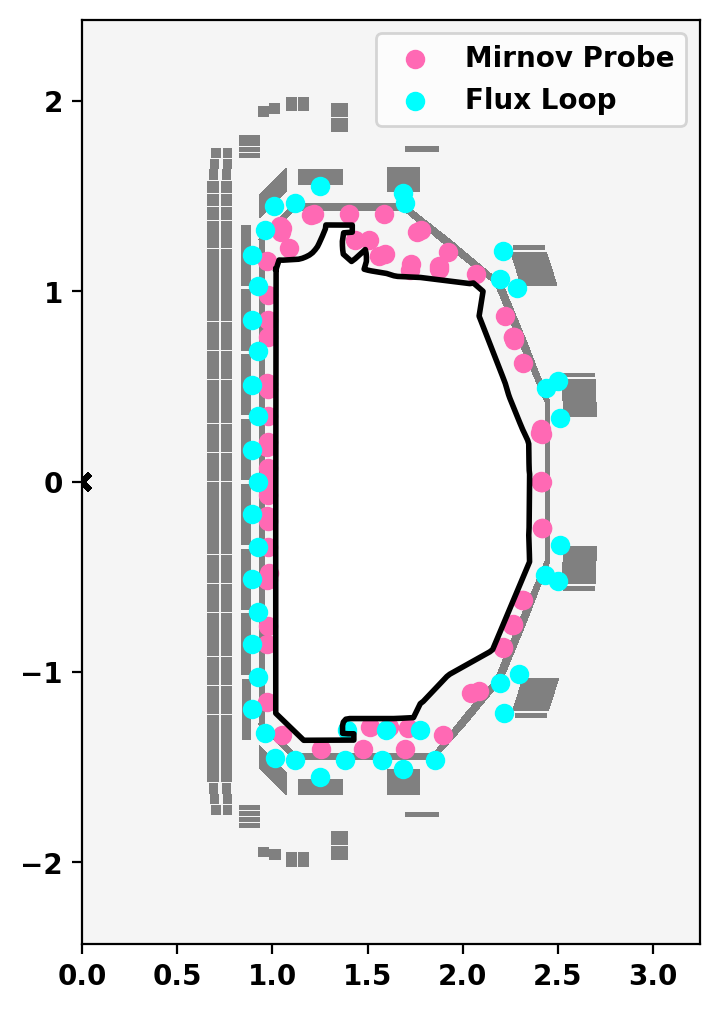

In [13]:
fig, ax = plt.subplots(1,1)
mygs.plot_machine(fig,ax,limiter_color='k')
mygs.plot_psi(fig,ax,plasma_nlevels=5,vacuum_nlevels=5)
mygs.plot_constraints(fig, ax)

def plot_sensors(sensors, label, color):
    r_coords = [s[0] for _,s in sensors.items()]
    z_coords = [s[1] for _,s in sensors.items()]
    ax.scatter(x=r_coords, y=z_coords, label=label, color=color)

plot_sensors(mag_sensors, label="Mirnov Probe", color='hotpink')
plot_sensors(flux_loops, label="Flux Loop", color='cyan')

ax.legend()
plt.show()

### Load Shot Data from DIII-D
Here we load data from a DIII-D k file representing a shot at a given point in time.

In [14]:
probes_dict, loops_dict, e_coil_dict, f_coil_dict, _ = read_kfile('DIIID_files/k'+shot_tag, machine_dict, e_coil_names, f_coil_names)

### Read Data From DIII-D to Mirnov Probes

In [15]:
def convert_Mirnov_coordinates(sensor):
    R, z, angle = sensor
    position = np.array([R, z])

    angle_rads = angle * np.pi / 180
    orientation = np.array([np.cos(angle_rads), 0, np.sin(angle_rads)])
    return position, orientation

B_vals = [probes_dict[key][0] for key in mag_sensors if key in probes_dict]
B_mean = np.mean(np.positive(B_vals))
mirnov_names = []

for key, mag in mag_sensors.items():
    if probes_dict[key][1] == 0:
        print("{} not selected.".format(key))
        continue
    position, orientation = convert_Mirnov_coordinates(mag)
    mirnov_names.append(key)
    B_meas, _ = probes_dict[key]
    myrecon.add_Mirnov(position, orientation, B_meas, err=0.1*max(B_mean, abs(B_meas)))


MPI66M247 not selected.
MPI79A147 not selected.
MPI6NA132 not selected.
MPI7NB322 not selected.
DSL3U180 not selected.
MPI5U157 not selected.
MPI6U157 not selected.
MPI7U157 not selected.
DSL5U157 not selected.
DSL6U157 not selected.
MPI3L180 not selected.


### Read Data From Equilibrium to Flux Loops

In [16]:
flux_locs = []
flux_vals = []

psi_vals = [loops_dict[key][0] for key in flux_loops if key in loops_dict]
psi_mean = np.mean(np.positive(psi_vals))

flux_names = []

for key, fl in flux_loops.items():
    if loops_dict[key][1] == 0:
        print("{} not selected.".format(key))
        continue
    flux_names.append(key)
    B_tmp, _ = loops_dict[key]
    flux_locs.append(fl)
    flux_vals.append(B_tmp)
    psi_val = B_tmp*2.0*np.pi
    myrecon.add_flux_loop(fl, psi_val, err=0.1*(max(psi_mean, abs(psi_val))))

mygs.set_flux(np.array(flux_locs), np.array(flux_vals))

PSF3A not selected.
PSF7NA not selected.
PSI34A not selected.
PSF6FB not selected.
PSI89FB not selected.
PSI2L not selected.


/var/folders/qz/wcp9q1mj0c5fsyjtbt99bvhh0000gn/T/ipykernel_19347/1324062342.py:20: DeprecationWarning: `set_flux()` is deprecated, use `set_psi_constraints()` instead. This function will be removed in a future version.
  mygs.set_flux(np.array(flux_locs), np.array(flux_vals))


## Profiles

Defined using experimental profiles + paramterized bump function. See King et al. (2017).

/var/folders/qz/wcp9q1mj0c5fsyjtbt99bvhh0000gn/T/ipykernel_19347/1437325844.py:24: RuntimeWarning: divide by zero encountered in scalar divide
  return f_0 * np.exp(-delta**2 / (1.5 **2 - psi_n ** 2)) + f_c


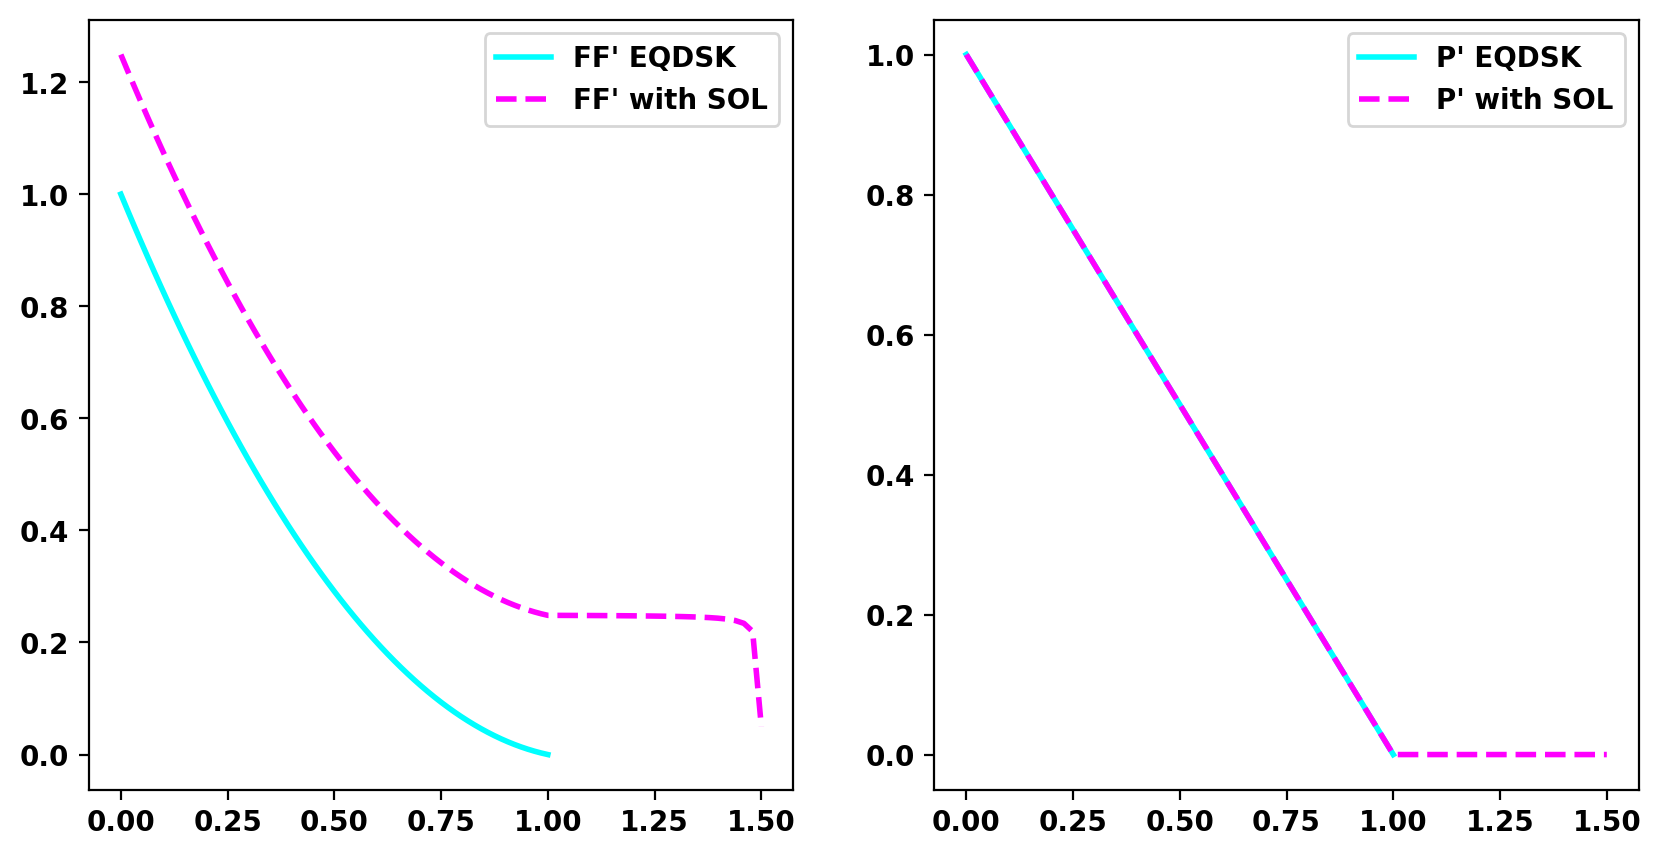

In [17]:
fig, ax = plt.subplots(1, 2, figsize=(10,5))
ffprim = eqdsk['ffprim']
pprime = eqdsk['pprime']
x = np.linspace(0.0, 1.0, len(ffprim))

ffprim -= ffprim[-1]
ffprim = ffprim / ffprim[0]

pprime -= pprime[-1]
pprime = pprime / pprime[0]

ax[0].plot(x, ffprim, label='FF\' EQDSK', color='cyan')
ax[1].plot(x, pprime, label='P\' EQDSK', color='cyan')

x_sol = np.linspace(1.01, 1.5, 25)
x = np.append(x, x_sol)
pprime = np.append(pprime, len(x_sol) * [0.0])

f_c = 0.05
f_0 = 0.2
delta = 0.1
psi_sol = 1.0
def bump(psi_n):
    return f_0 * np.exp(-delta**2 / (1.5 **2 - psi_n ** 2)) + f_c

ffp_bump = [bump(x0) for x0 in x]
ffprim = np.append(ffprim, len(x_sol) * [0.0]) + ffp_bump

ax[0].plot(x, ffprim, label='FF\' with SOL', linestyle='--', color='magenta')
ax[1].plot(x, pprime, label='P\' with SOL', linestyle='--', color='magenta')

ax[0].legend()
ax[1].legend()
plt.show()

mygs.set_profiles(ffp_prof={'type': 'linterp', 'y': ffprim, 'x': x},pp_prof={'type': 'linterp', 'y': pprime, 'x': x}, f_SOL=True)


## Compute starting equilibrium

In [18]:
##### Add plasma current and flux loop constraints
Ip_target=abs(eqdsk['ip'])
P0_target=eqdsk['pres'][0]
mygs.set_targets(Ip=Ip_target, pax=P0_target)

target_currents = {}
target_errs = {}

for key in e_coil_dict:
    if e_coil_dict[key][1] == 0:
        continue
    target_currents[key] = e_coil_dict[key][0]
    target_errs[key] = abs(e_coil_dict[key][1])

for key in f_coil_dict:
    if f_coil_dict[key][1] == 0:
        continue
    target_currents[key] = f_coil_dict[key][0] / machine_dict['FCOIL'][key][4]
    target_errs[key] = abs(f_coil_dict[key][1] / machine_dict['FCOIL'][key][4])

# Set coil regularization to weakly track measured coil currents
regularization_terms = []
for key in e_coil_dict:
    if e_coil_dict[key][1] == 0:
        continue
    regularization_terms.append(mygs.coil_reg_term({key: 1.0},
                                                   target=target_currents[key],
                                                   weight=1.0E1))
for key in f_coil_dict:
    if f_coil_dict[key][1] == 0:
            continue
    regularization_terms.append(mygs.coil_reg_term({key: 1.0},
                                                   target=target_currents[key],
                                                   weight=1.0E2))

# Set zero target current and small weight on virtual VSC to allow up-down adjustment
regularization_terms.append(mygs.coil_reg_term({'#VSC': 1.0},target=0.0,weight=1.E-2))

# Pass regularization terms to TokaMaker
mygs.set_coil_reg(reg_terms=regularization_terms)

# Initial equilibrium with very rough guess
R0 = eqdsk['rcentr']
Z0 = 0.0
a = 0.6
kappa = 1.13
delta = .1

err_flag = mygs.init_psi(R0, Z0, a, kappa, delta)

# Compute initial equilibrium
mygs.settings.maxits=500
mygs.update_settings()
mygs.solve()

Starting non-linear GS solver
     1  5.7602E-01  1.0547E+00  1.3725E-02  1.7535E+00 -1.5827E-02  9.3190E+01
     2  1.2820E+00  9.4553E-01  4.4836E-03  1.7536E+00 -1.9282E-02  9.5331E+01
     3  1.4085E+00  9.5799E-01  1.1704E-02  1.7516E+00 -2.2414E-02  9.3748E+01
     4  1.4767E+00  9.5852E-01  1.2952E-02  1.7494E+00 -2.5322E-02  9.1983E+01
     5  1.5014E+00  9.6001E-01  1.2922E-02  1.7474E+00 -2.8066E-02  9.0191E+01
     6  1.5098E+00  9.6090E-01  1.2263E-02  1.7459E+00 -3.0611E-02  8.8543E+01
     7  1.5113E+00  9.6145E-01  1.1423E-02  1.7449E+00 -3.2974E-02  8.7075E+01
     8  1.5100E+00  9.6176E-01  1.0564E-02  1.7442E+00 -3.5146E-02  8.5778E+01
     9  1.5077E+00  9.6191E-01  9.7460E-03  1.7437E+00 -3.7187E-02  8.4632E+01
    10  1.5052E+00  9.6195E-01  8.9869E-03  1.7434E+00 -3.9077E-02  8.3615E+01
    11  1.5028E+00  9.6193E-01  8.2916E-03  1.7431E+00 -4.0825E-02  8.2705E+01
    12  1.5004E+00  9.6186E-01  7.6536E-03  1.7430E+00 -4.2443E-02  8.1885E+01
    13  1.4983E+00  9.

## Plot starting equilibrium

Equilibrium Statistics:
  Topology                =   Diverted
  Toroidal Current [A]    =    1.3099E+06
  Current Centroid [m]    =    1.665 -0.055
  Magnetic Axis [m]       =    1.743 -0.062
  Elongation              =    1.881 (U:  1.984, L:  1.777)
  Triangularity           =    0.737 (U:  0.726, L:  0.749)
  Plasma Volume [m^3]     =   19.700
  q_0, q_95               =   -1.147 -5.516
  Plasma Pressure [Pa]    =   Axis:  1.1626E+05, Peak:  1.1626E+05
  Stored Energy [J]       =    8.2545E+05
  <Beta_pol> [%]          =   83.8230
  <Beta_tor> [%]          =    1.4802
  <Beta_n>   [%]          =    1.4812
  Diamagnetic flux [Wb]   =   -1.5992E-02
  Toroidal flux [Wb]      =   -4.6910E+00
  l_i                     =    1.1072


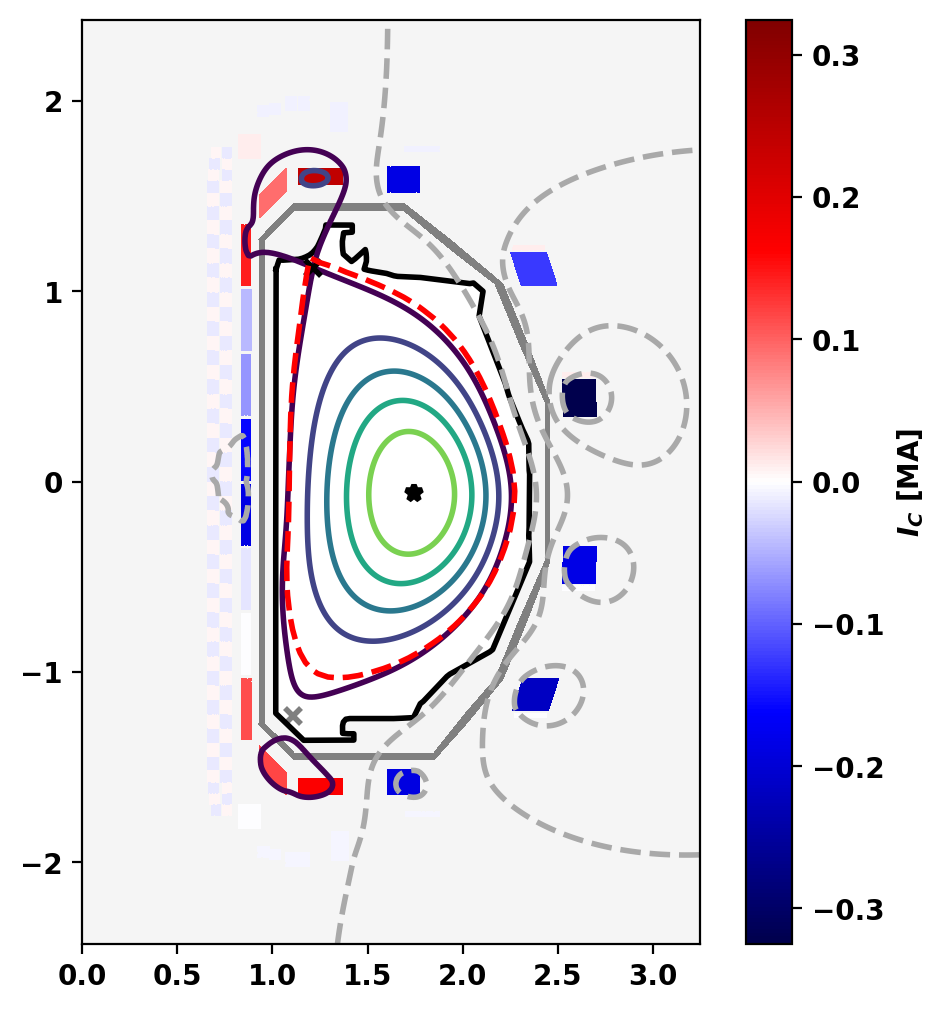

In [19]:
psi_eq = mygs.get_psi()
mygs.print_info()

fig, ax = plt.subplots(1,1)
mygs.plot_machine(fig,ax,coil_colormap='seismic',coil_scale=1.E-6,coil_clabel=r'$I_C$ [MA]',coil_symmap=True)
mygs.plot_psi(fig,ax,normalized=True,plasma_nlevels=6,vacuum_nlevels=5)
# mygs.plot_psi(fig,ax,psi_eq,plasma_levels=[1.0,],plasma_color='red',vacuum_nlevels=0,plasma_linestyles='dashed')
_ = ax.plot(eqdsk['rzout'][:,0], eqdsk['rzout'][:,1],'r--')
# plot_sensors({**fluxLoops_vv, **fluxLoops_onf}, label="Flux Loop", color='cyan')

plt.show()

In [20]:
print("Coil Currents [kA]:")
coil_currents, _ = mygs.get_coil_currents()
for key, current in coil_currents.items():
    if key not in target_currents:
        continue
    current_adj = current
    # if key.startswith('F'):
    #     current_adj = current/machine_dict['FCOIL'][key][4]
    measured_currt = target_currents[key]
    pct_diff = 100.0 * (current_adj-measured_currt)/measured_currt
    print('  {0:10} {1:11.3F} {2:11.3F} {3:10.2F}%'.format(key+":", current_adj/1.E3, measured_currt/1.E3, pct_diff))

Coil Currents [kA]:
  F1A:            -2.738      -2.754      -0.59%
  F2A:            -1.146      -1.163      -1.50%
  F3A:            -0.750      -0.758      -1.13%
  F4A:             2.484       2.485      -0.03%
  F5A:             1.590       1.601      -0.70%
  F6A:            -5.903      -5.924      -0.36%
  F7A:            -2.269      -2.272      -0.14%
  F8A:             4.157       4.168      -0.25%
  F9A:            -3.389      -3.480      -2.62%
  F1B:            -3.231      -3.237      -0.19%
  F2B:            -0.305      -0.299       1.81%
  F3B:            -0.039      -0.027      44.46%
  F4B:             1.957       1.970      -0.65%
  F5B:             2.019       2.032      -0.63%
  F6B:            -3.347      -3.363      -0.47%
  F7B:            -3.939      -3.944      -0.14%
  F8B:             2.864       2.873      -0.32%
  F9B:            -3.431      -3.377       1.59%


## Plot Measured vs. Computed SE Values

### Plot SE Currents

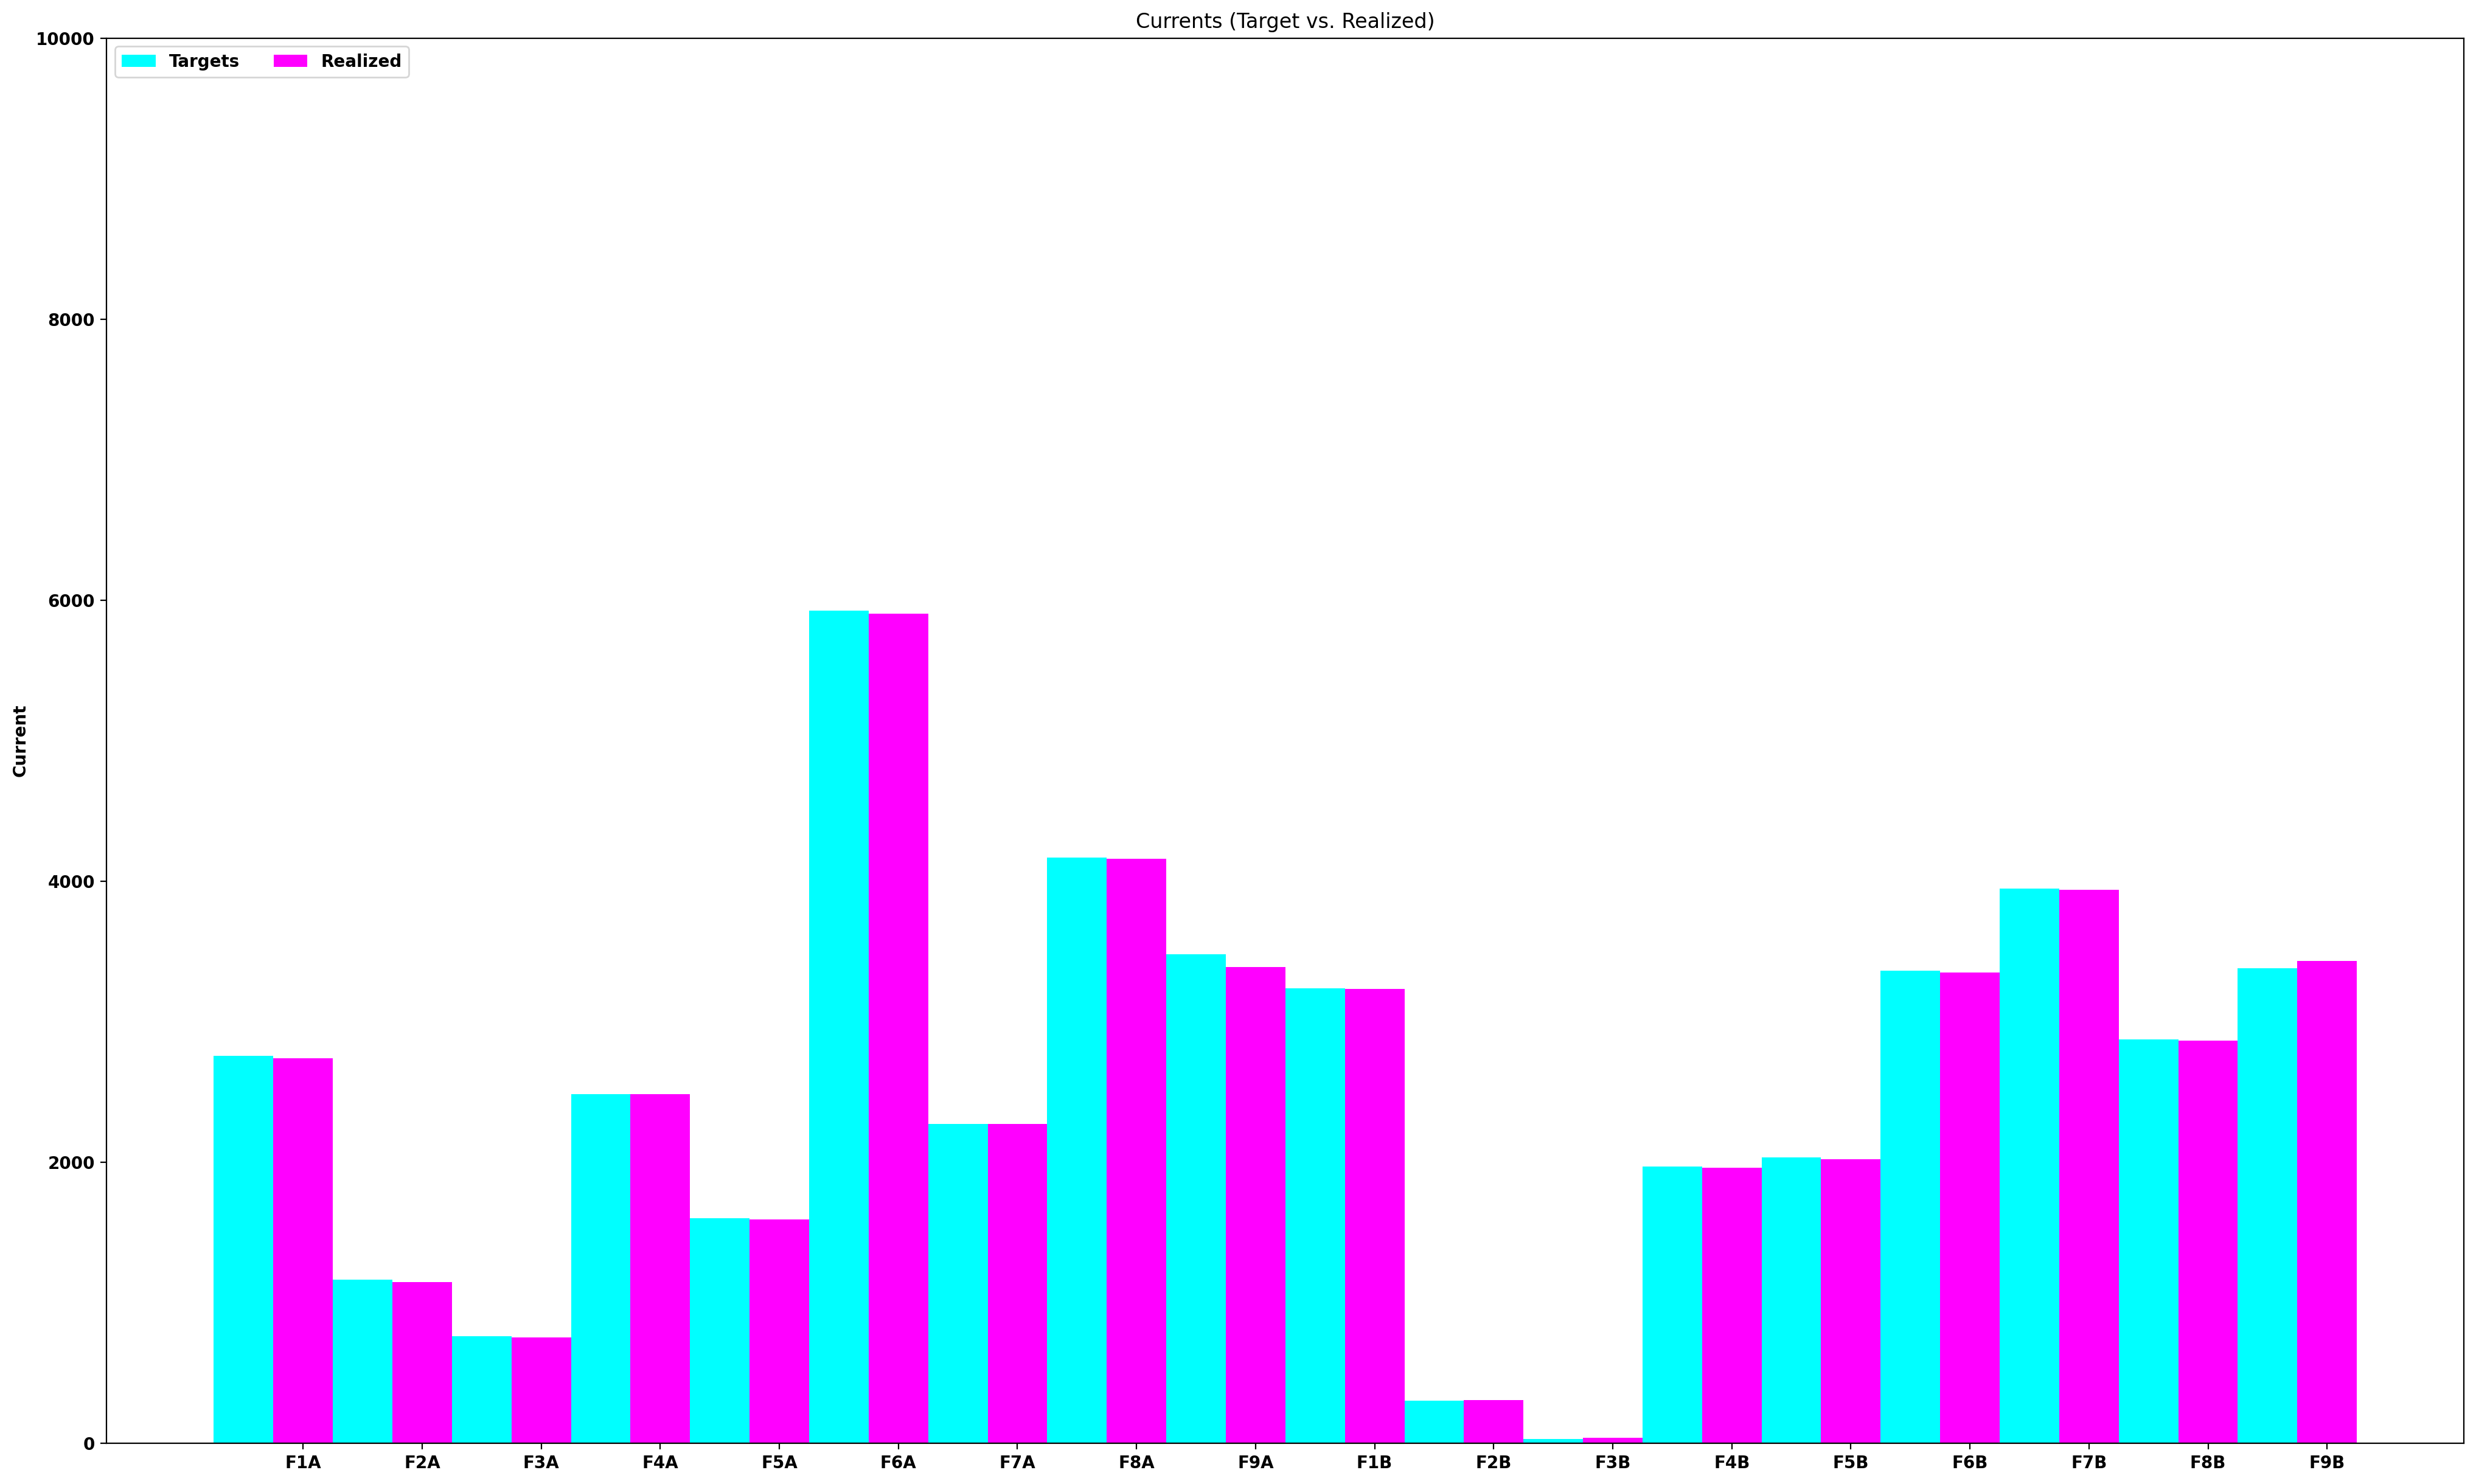

In [21]:
plot_colors = {'Targets': 'cyan', 'Realized': 'magenta', 'Error': 'blue'}

def plot_currents():
    coil_currents, _ = mygs.get_coil_currents()
    coil_names = [key for key in coil_currents if key in target_currents]
    coil_info = {'Targets': [abs(target_currents[key]) for key in coil_names if key in target_currents],
                 'Realized': [abs(coil_currents[key]) for key in coil_names if key in target_currents]}
    coil_err = np.array([np.abs(target_errs[key]) for key in coil_names if key in target_currents])

    x = np.arange(len(coil_names))  # the label locations
    width = 0.5  # the width of the bars
    multiplier = 0
    
    fig, ax = plt.subplots(figsize=(25, 15))
    
    for attribute, measurement in coil_info.items():
        offset = width * multiplier
        rects = ax.bar(x + offset, measurement, width, label=attribute, color=plot_colors[attribute])
        multiplier += 1
    
    ax.set_ylabel('Current')
    ax.set_title('Currents (Target vs. Realized)')
    ax.set_xticks(x + width, coil_names)
    ax.legend(loc='upper left', ncols=3)
    ax.set_ylim(0, 1.0E4)

    x_c = np.arange(len(coil_names))

    plt.show()

plot_currents()

### Plot SE Sensors

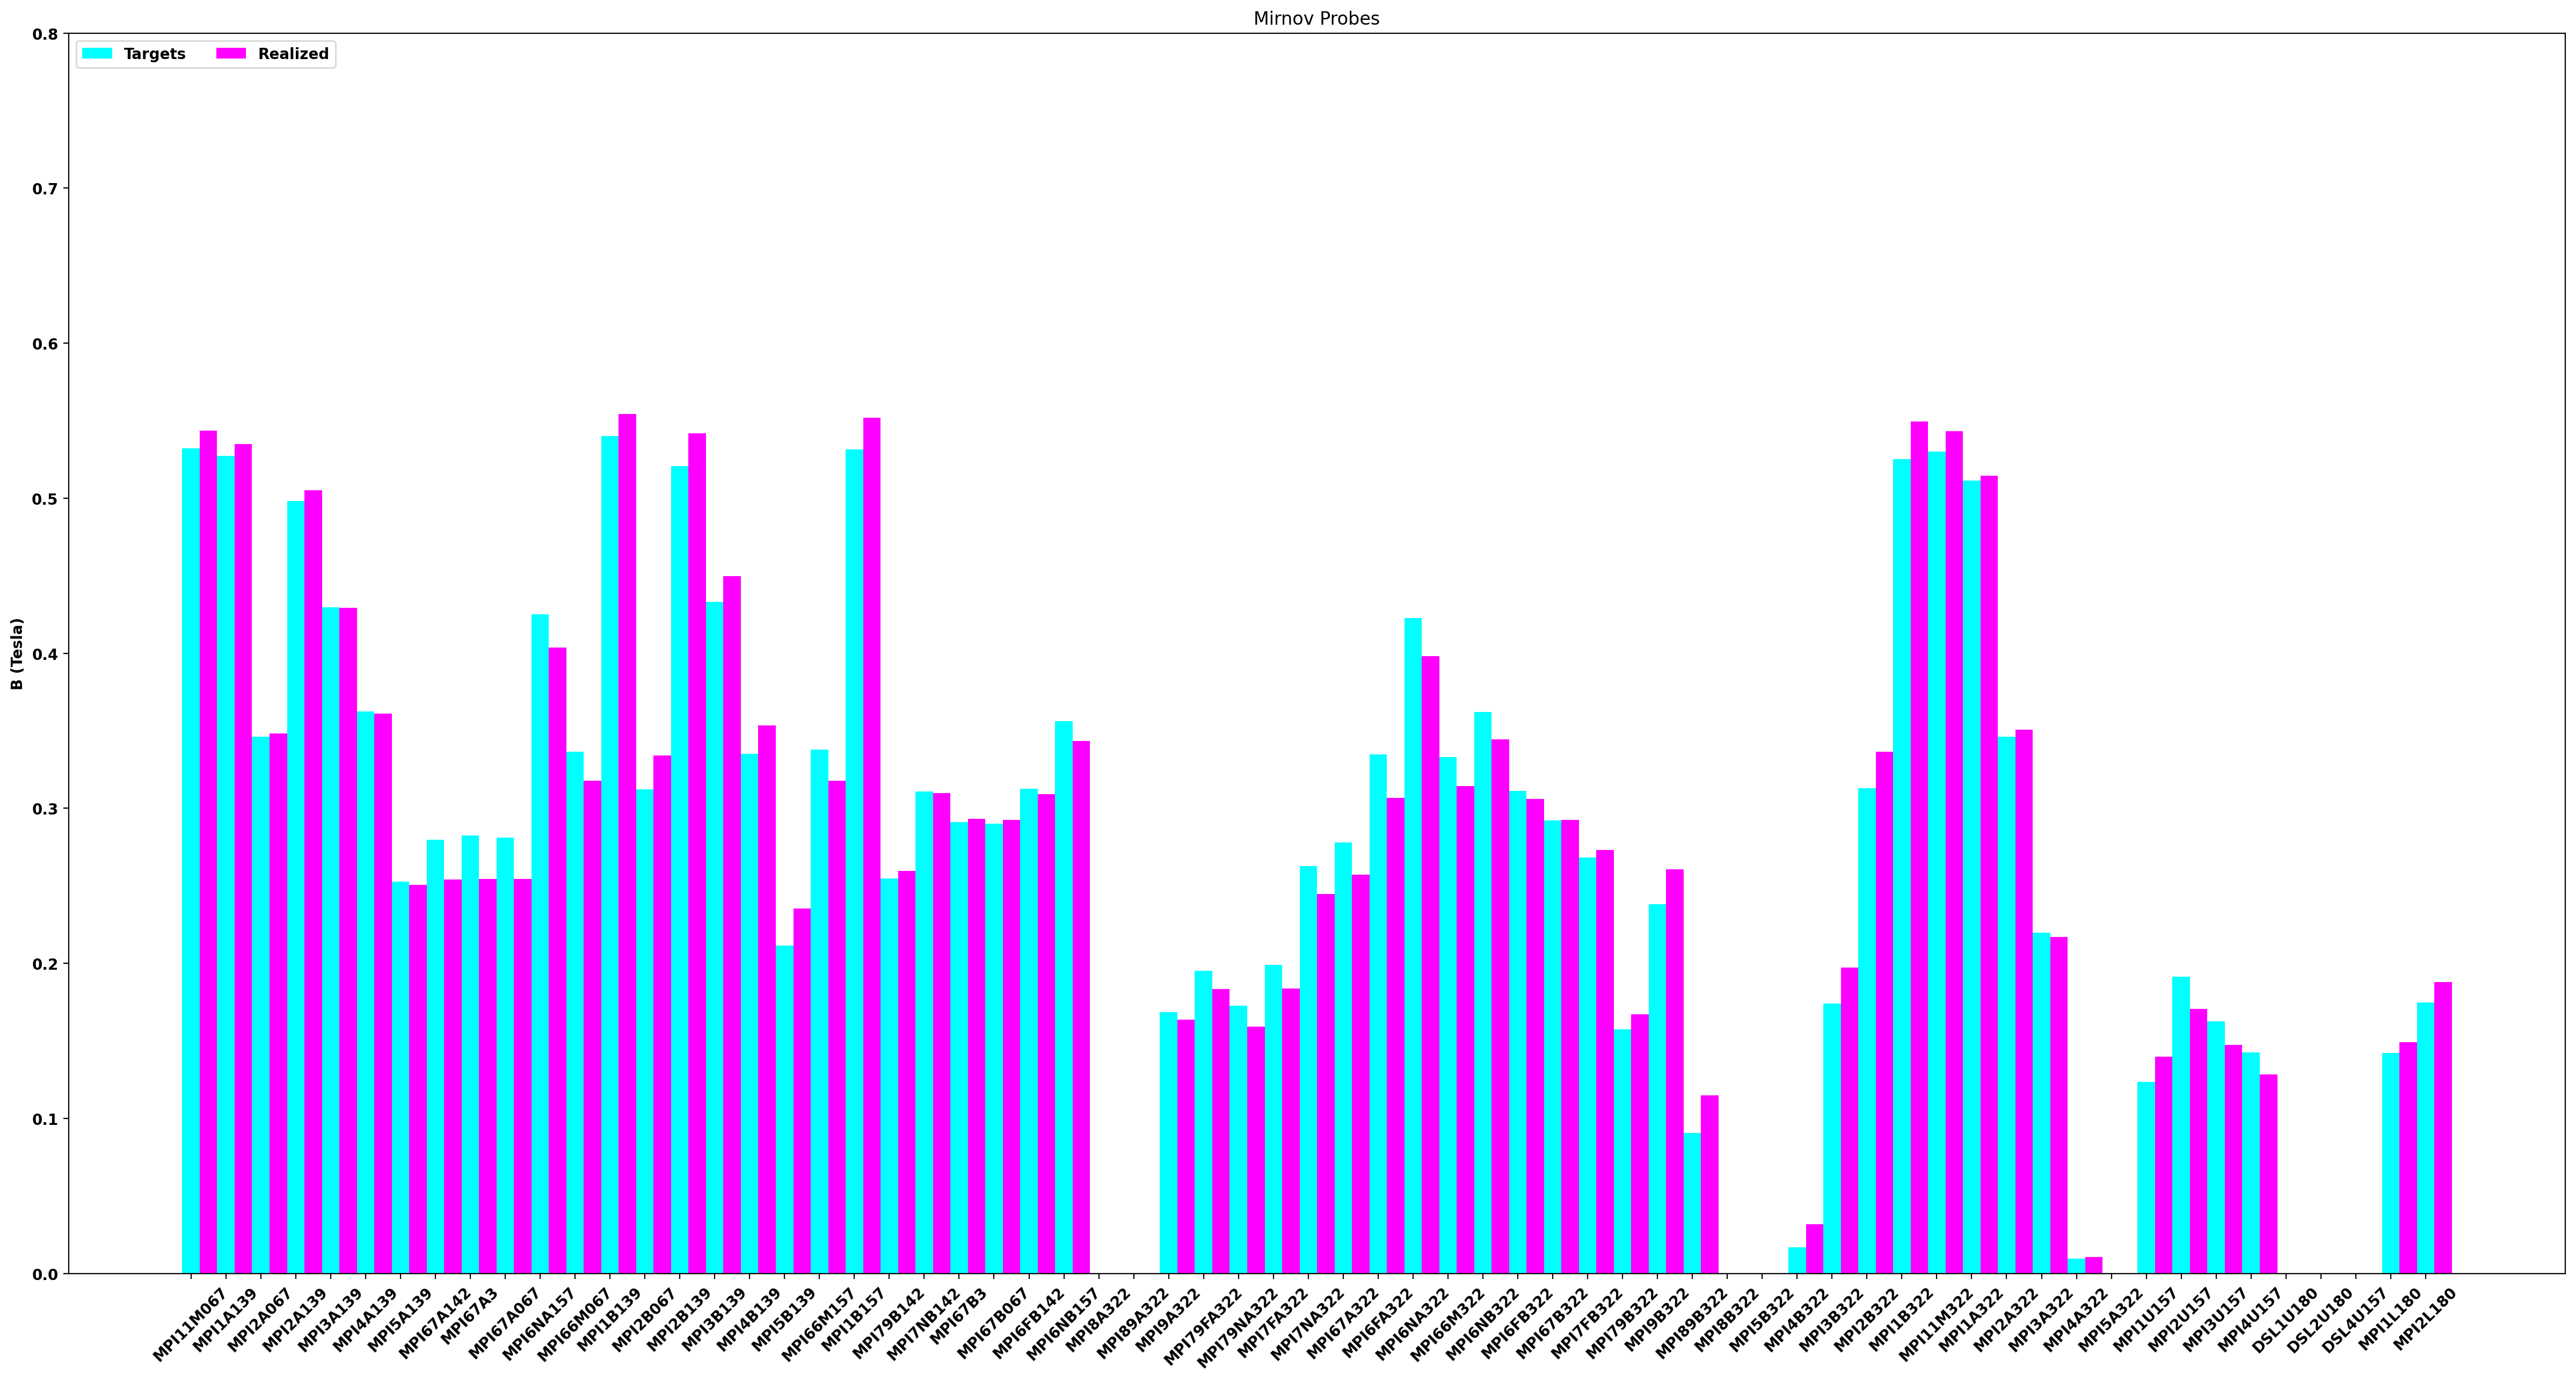

In [22]:
def plot_mirnov():
    mirnov_vals = []
    B_eval = mygs.get_field_eval('B')
    for key in mirnov_names:
        coords = mag_sensors[key]
        position, orientation = convert_Mirnov_coordinates(coords)
        B_field = B_eval.eval(position)
        mirnov_vals.append(np.dot(B_field, orientation))
    
    mirnov_targets = [probes_dict[key][0] if key in probes_dict else 0.0 for key in mirnov_names]
    mirnov_info = {'Targets': mirnov_targets,
                 'Realized': mirnov_vals}
    
    x_m = np.arange(len(mirnov_names))  # the label locations
    width = 0.5  # the width of the bars
    multiplier = 0
    
    fig, ax = plt.subplots(1, figsize=(30, 15))
    
    for attribute, measurement in mirnov_info.items():
        offset = width * multiplier
        rects_m = ax.bar(x_m + offset, measurement, width, label=attribute, color=plot_colors[attribute])
        multiplier += 1
    
    ax.set_ylabel('B (Tesla)')
    ax.set_title('Mirnov Probes')
    ax.legend(loc='upper left', ncols=3)
    ax.set_ylim(0, 0.8)
    ax.set_xticks(x_m, labels=mirnov_names, rotation=45)

    x_m = np.arange(len(mirnov_names))  # the label locations
    mirnov_mean = np.mean((np.abs(mirnov_targets)))

    plt.show()

plot_mirnov()

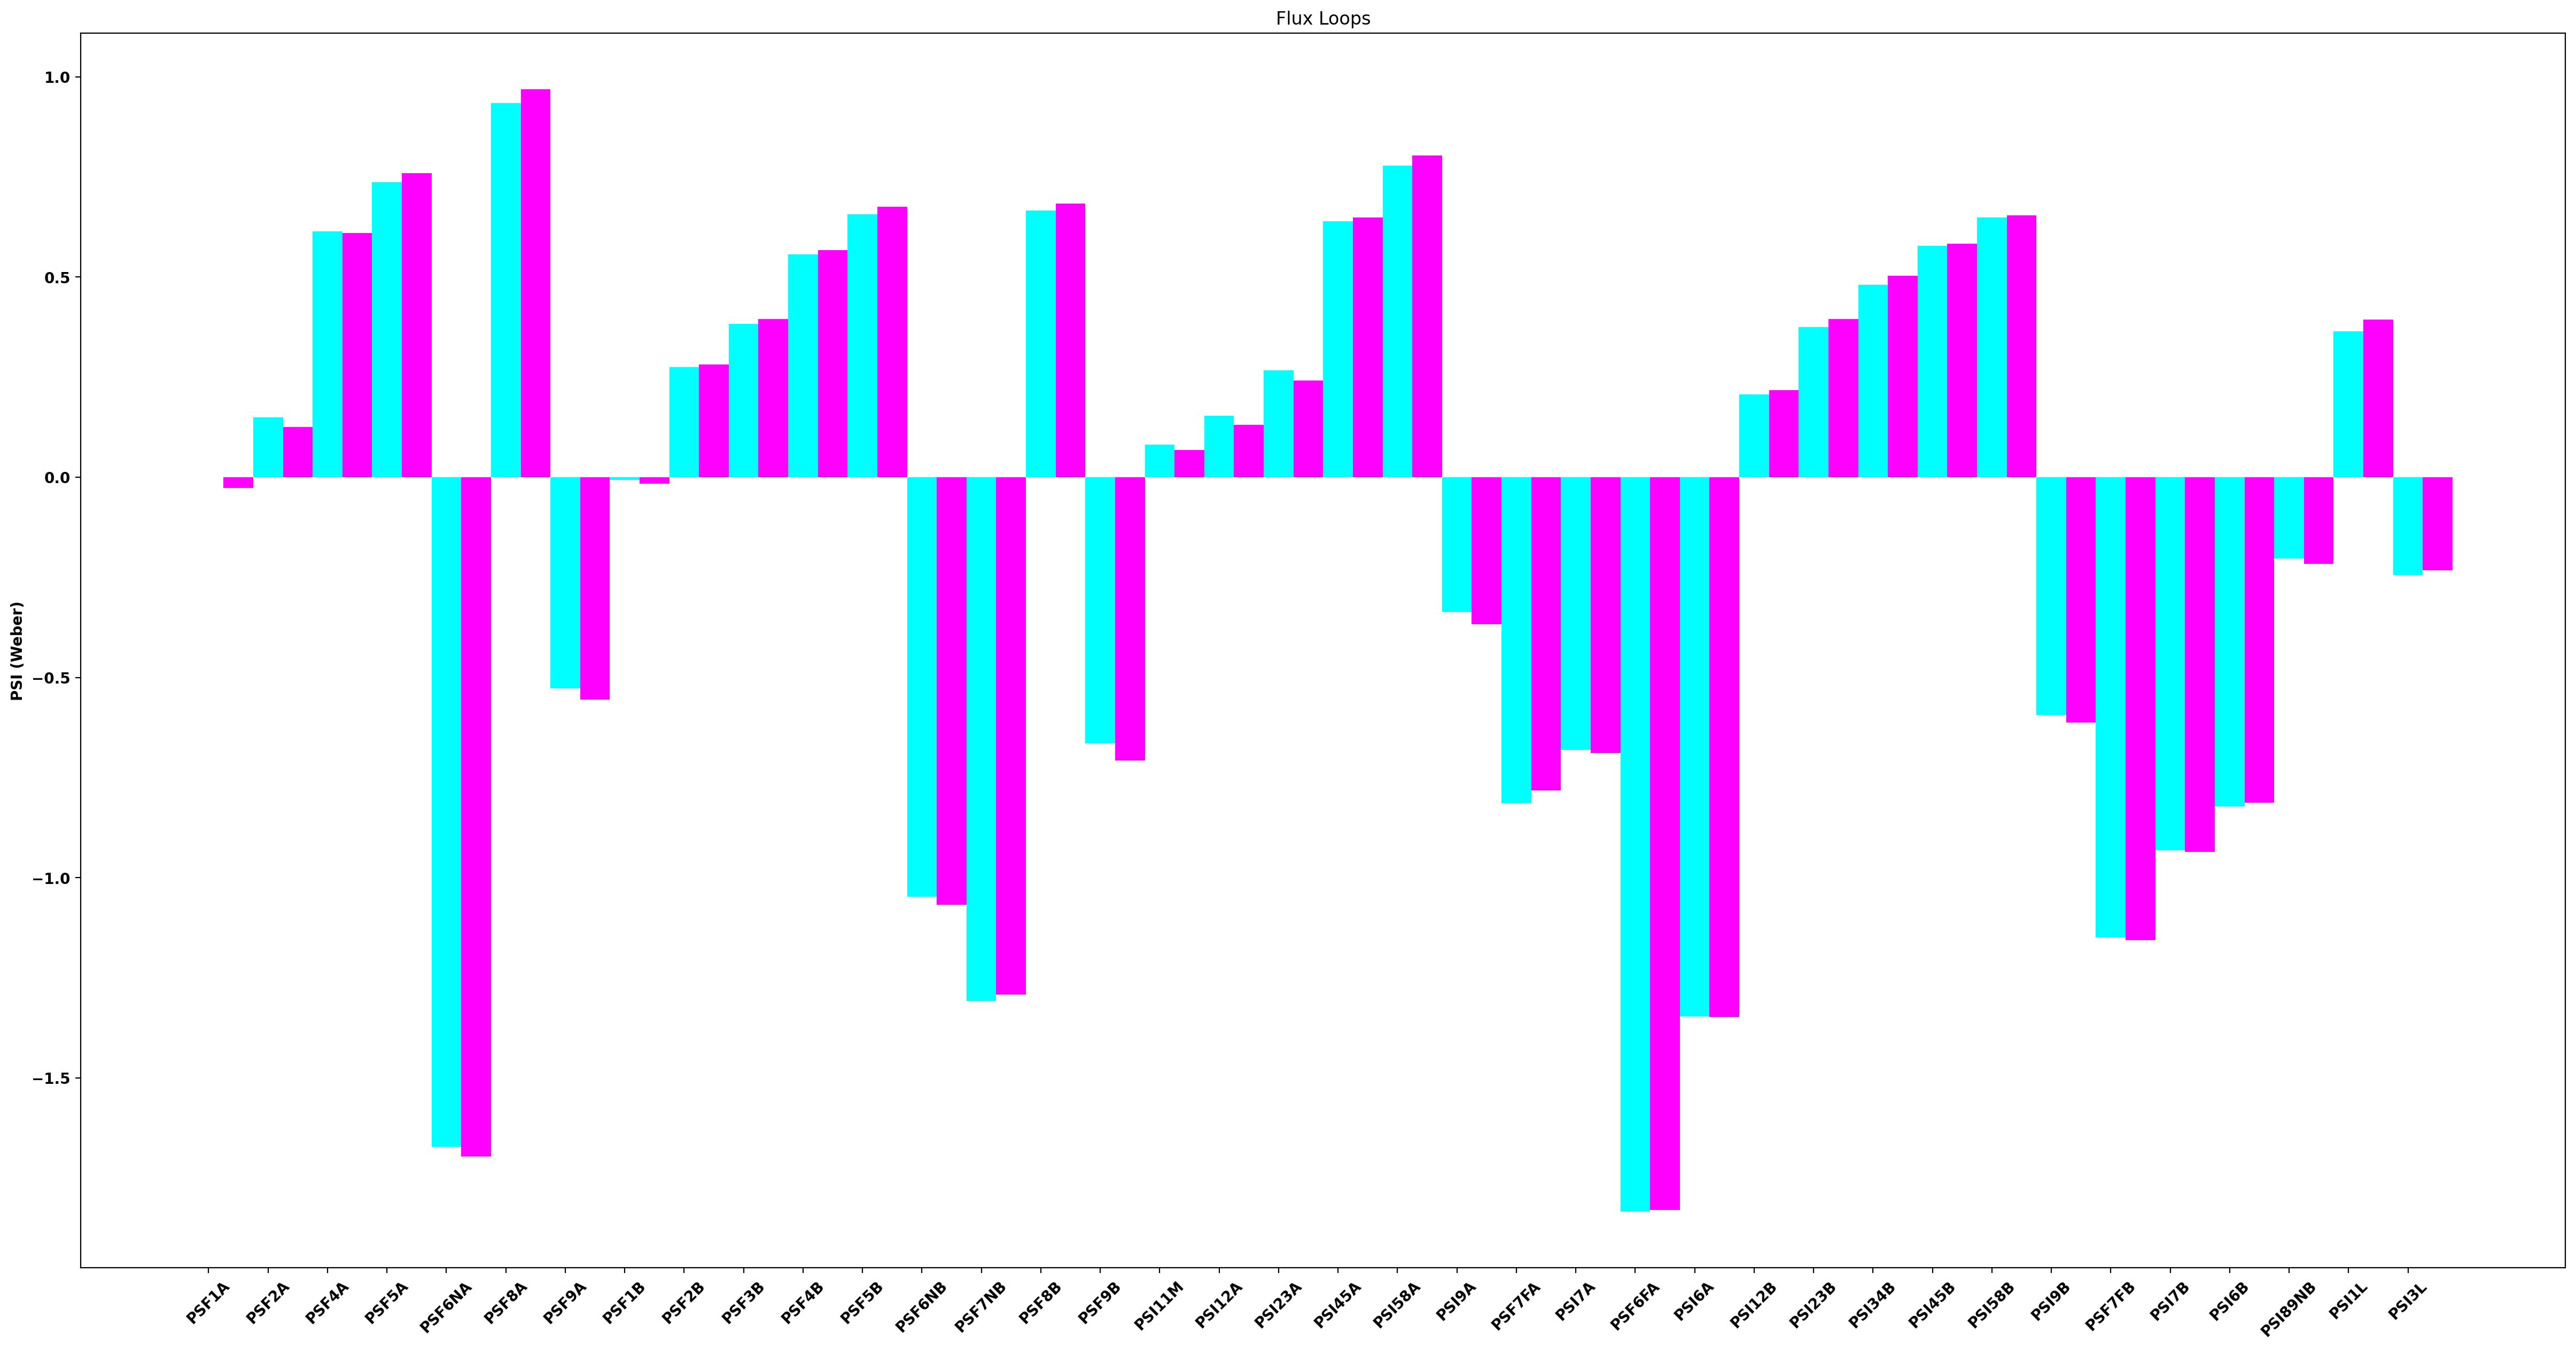

In [23]:
from matplotlib.patches import Patch

def plot_flux():
    flux_vals = []
    psi_eval = mygs.get_field_eval('PSI')
    for key in flux_names:
        position = flux_loops[key]
        psi_value = psi_eval.eval(position) * 2 * np.pi
        flux_vals.append(psi_value[0])

    flux_targets = [2 * np.pi * loops_dict[key][0] for key in flux_names]
    flux_errs = [2 * np.pi * loops_dict[key][1] for key in flux_names]

    figs, ax = plt.subplots(1, figsize=(30, 15))

    x_f = np.arange(len(flux_names))  # the label locations
    ax.bar(x = x_f, height = flux_targets, width=0.5, label='Targets', color=plot_colors['Targets'])
    ax.bar(x = x_f + 0.5, height = flux_vals, width=0.5, label='Realized', color=plot_colors['Realized'])

    ax.set_ylabel('PSI (Weber)')
    ax.set_title('Flux Loops')
    # ax.set_ylim(0, 1.5)
    ax.set_xticks(x_f, labels=flux_names, rotation=45)

    # ax.errorbar(x_f, flux_targets, yerr=1.0/np.abs(np.array(flux_errs)), color=plot_colors['Error'], linestyle='none', elinewidth=6.0)

    plt.show()

plot_flux()

### Perform Reconstruction

In [24]:
# Remove all shape constraints
mygs.set_isoflux(None)
mygs.set_flux(None,None)
mygs.set_saddles(None)

# Set initial position targets from current values
mygs.set_targets(R0=mygs.o_point[0],V0=mygs.o_point[1])

# Set Recon Plasma Current
myrecon.set_Ip(Ip_target, err=0.1*Ip_target)

# Set reconstruction settings
myrecon.settings.fit_Pscale = False
myrecon.settings.fitR0 = True
myrecon.settings.fitZ0 = True
myrecon.settings.fitCoils = True
myrecon.settings.pm = False

# Perform reconstructions
mygs.settings.nl_tol=1.E-6
err_flag = myrecon.reconstruct()

/var/folders/qz/wcp9q1mj0c5fsyjtbt99bvhh0000gn/T/ipykernel_19347/1598217038.py:2: DeprecationWarning: `set_isoflux()` is deprecated, use `set_isoflux_constraints()` instead. This function will be removed in a future version.
  mygs.set_isoflux(None)
/var/folders/qz/wcp9q1mj0c5fsyjtbt99bvhh0000gn/T/ipykernel_19347/1598217038.py:3: DeprecationWarning: `set_flux()` is deprecated, use `set_psi_constraints()` instead. This function will be removed in a future version.
  mygs.set_flux(None,None)
/var/folders/qz/wcp9q1mj0c5fsyjtbt99bvhh0000gn/T/ipykernel_19347/1598217038.py:4: DeprecationWarning: `set_saddles()` is deprecated, use `set_saddle_constraints()` instead. This function will be removed in a future version.
  mygs.set_saddles(None)
/var/folders/qz/wcp9q1mj0c5fsyjtbt99bvhh0000gn/T/ipykernel_19347/1598217038.py:7: DeprecationWarning: `V0` is deprecated, use `Z0` instead. This argument will be removed in a future version.
  mygs.set_targets(R0=mygs.o_point[0],V0=mygs.o_point[1])



*** Loading fit constraints ***

Starting Fit:
  # of free parameters   =   26
  # of constraints       =  104

Function evaluation    1
  FFp_scale         =  1.472E+00
  P_scale           =  9.600E-01
  R0_target         =  1.743E+00
  Z0_target         = -6.221E-02
  Coil currents [%]  = -0.000E+00 -0.000E+00 -0.000E+00  0.000E+00  0.000E+00 -0.000E+00 -0.000E+00  0.000E+00 -0.000E+00 -0.000E+00 -0.000E+00 -0.000E+00  0.000E+00  0.000E+00 -0.000E+00 -0.000E+00  0.000E+00 -0.000E+00 -0.000E+00  0.000E+00  0.000E+00 -0.000E+00 -0.000E+00 -0.000E+00
  Maximum Rel Error =  5.886E+02
  Maximum Abs Error =  9.032E+05
  Total Weighted Error   =  5.886E+03
  RMS Weighted Error     =  5.772E+02

Function evaluation    2
  FFp_scale         =  1.472E+00
  P_scale           =  9.600E-01
  R0_target         =  1.743E+00
  Z0_target         = -6.221E-02
  Coil currents [%]  = -0.000E+00 -0.000E+00 -0.000E+00  0.000E+00  0.000E+00 -0.000E+00 -0.000E+00  0.000E+00 -0.000E+00 -0.000E+00 -0.000E+00

### Print equilibrium information and coil currents
As above we use \ref OpenFUSIONToolkit.TokaMaker.TokaMaker.print_info "print_info()" and \ref OpenFUSIONToolkit.TokaMaker.TokaMaker.get_coil_currents "get_coil_currents()" to display information on the final equilibrium.

In [25]:
mygs.print_info()

print()
print("Coil Currents [kA]:")
coil_currents, _ = mygs.get_coil_currents()
for key, current in coil_currents.items():
    if key not in target_currents:
        continue
    measured_currt = target_currents[key]
    pct_diff = 100.0 * (current-measured_currt)/measured_currt
    print('  {0:10} {1:11.3F} {2:11.3F} {3:10.2F}%'.format(key+":", current/1.E3, measured_currt/1.E3, pct_diff))

Equilibrium Statistics:
  Topology                =   Diverted
  Toroidal Current [A]    =    1.2681E+06
  Current Centroid [m]    =    1.670  0.005
  Magnetic Axis [m]       =    1.742 -0.010
  Elongation              =    1.854 (U:  2.022, L:  1.685)
  Triangularity           =    0.672 (U:  0.806, L:  0.537)
  Plasma Volume [m^3]     =   18.550
  q_0, q_95               =   -1.121 -5.026
  Plasma Pressure [Pa]    =   Axis:  1.1721E+05, Peak:  1.1721E+05
  Stored Energy [J]       =    7.9312E+05
  <Beta_pol> [%]          =   82.3999
  <Beta_tor> [%]          =    1.5355
  <Beta_n>   [%]          =    1.5108
  Diamagnetic flux [Wb]   =   -1.4741E-02
  Toroidal flux [Wb]      =   -4.3436E+00
  l_i                     =    1.0799

Coil Currents [kA]:
  F1A:            -2.648      -2.754      -3.85%
  F2A:            -1.259      -1.163       8.20%
  F3A:            -0.591      -0.758     -22.04%
  F4A:             2.612       2.485       5.12%
  F5A:             1.485       1.601      -7

## Plot final reconstructed equilibrium

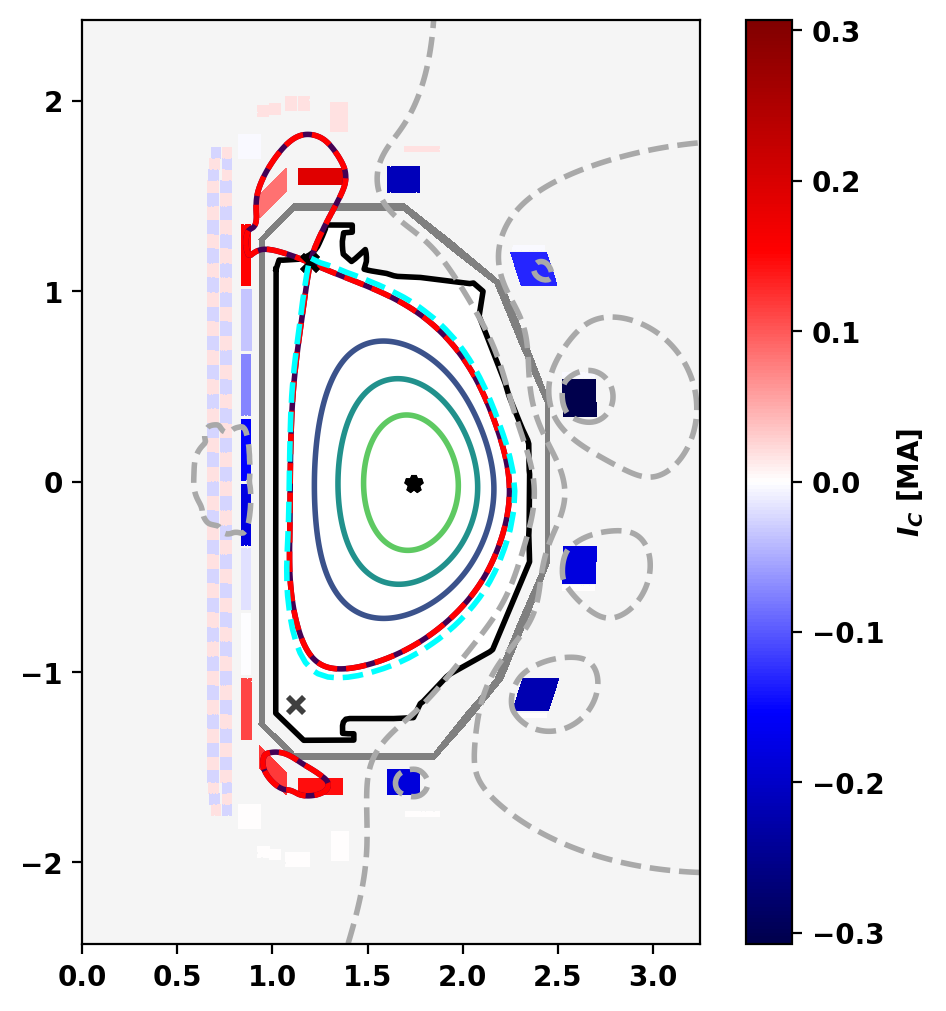

In [26]:
# Plot Psi
psi_recons = mygs.get_psi()
fig, ax = plt.subplots(1,1)
mygs.plot_machine(fig,ax,coil_colormap='seismic',coil_scale=1.E-6,coil_clabel=r'$I_C$ [MA]',coil_symmap=True)
mygs.plot_psi(fig,ax,plasma_nlevels=5,vacuum_nlevels=5)
mygs.plot_psi(fig,ax,psi=psi_recons,plasma_levels=[1.0,],plasma_color='red',vacuum_nlevels=0,plasma_linestyles='dashed')

LCFS_eqdsk = eqdsk['rzout']
ax.plot(LCFS_eqdsk[:,0], LCFS_eqdsk[:,1], color='cyan', linestyle='--')

plt.show()

## Plot Current Density

Starting CG solver
     0  0.000000E+00  0.000000E+00  3.019790E-01
     1 -4.272369E+02  4.316285E+03  7.366056E-02  1.706573E-05
     2 -5.066968E+02  6.570924E+03  2.388534E-02  3.635005E-06
     3 -5.134447E+02  6.697639E+03  9.863127E-03  1.472628E-06
     4 -5.143778E+02  6.703356E+03  3.678389E-03  5.487384E-07
     5 -5.145378E+02  6.707104E+03  1.442207E-03  2.150267E-07
     6 -5.145577E+02  6.710738E+03  5.023622E-04  7.485946E-08
     7 -5.145603E+02  6.710444E+03  1.783923E-04  2.658427E-08
     8 -5.145606E+02  6.710697E+03  7.258678E-05  1.081658E-08
     9 -5.145607E+02  6.710666E+03  2.996763E-05  4.465672E-09
    10 -5.145607E+02  6.710693E+03  1.247669E-05  1.859225E-09
    20 -5.145607E+02  6.710710E+03  7.689114E-10  1.145797E-13


TypeError: list.append() takes exactly one argument (3 given)

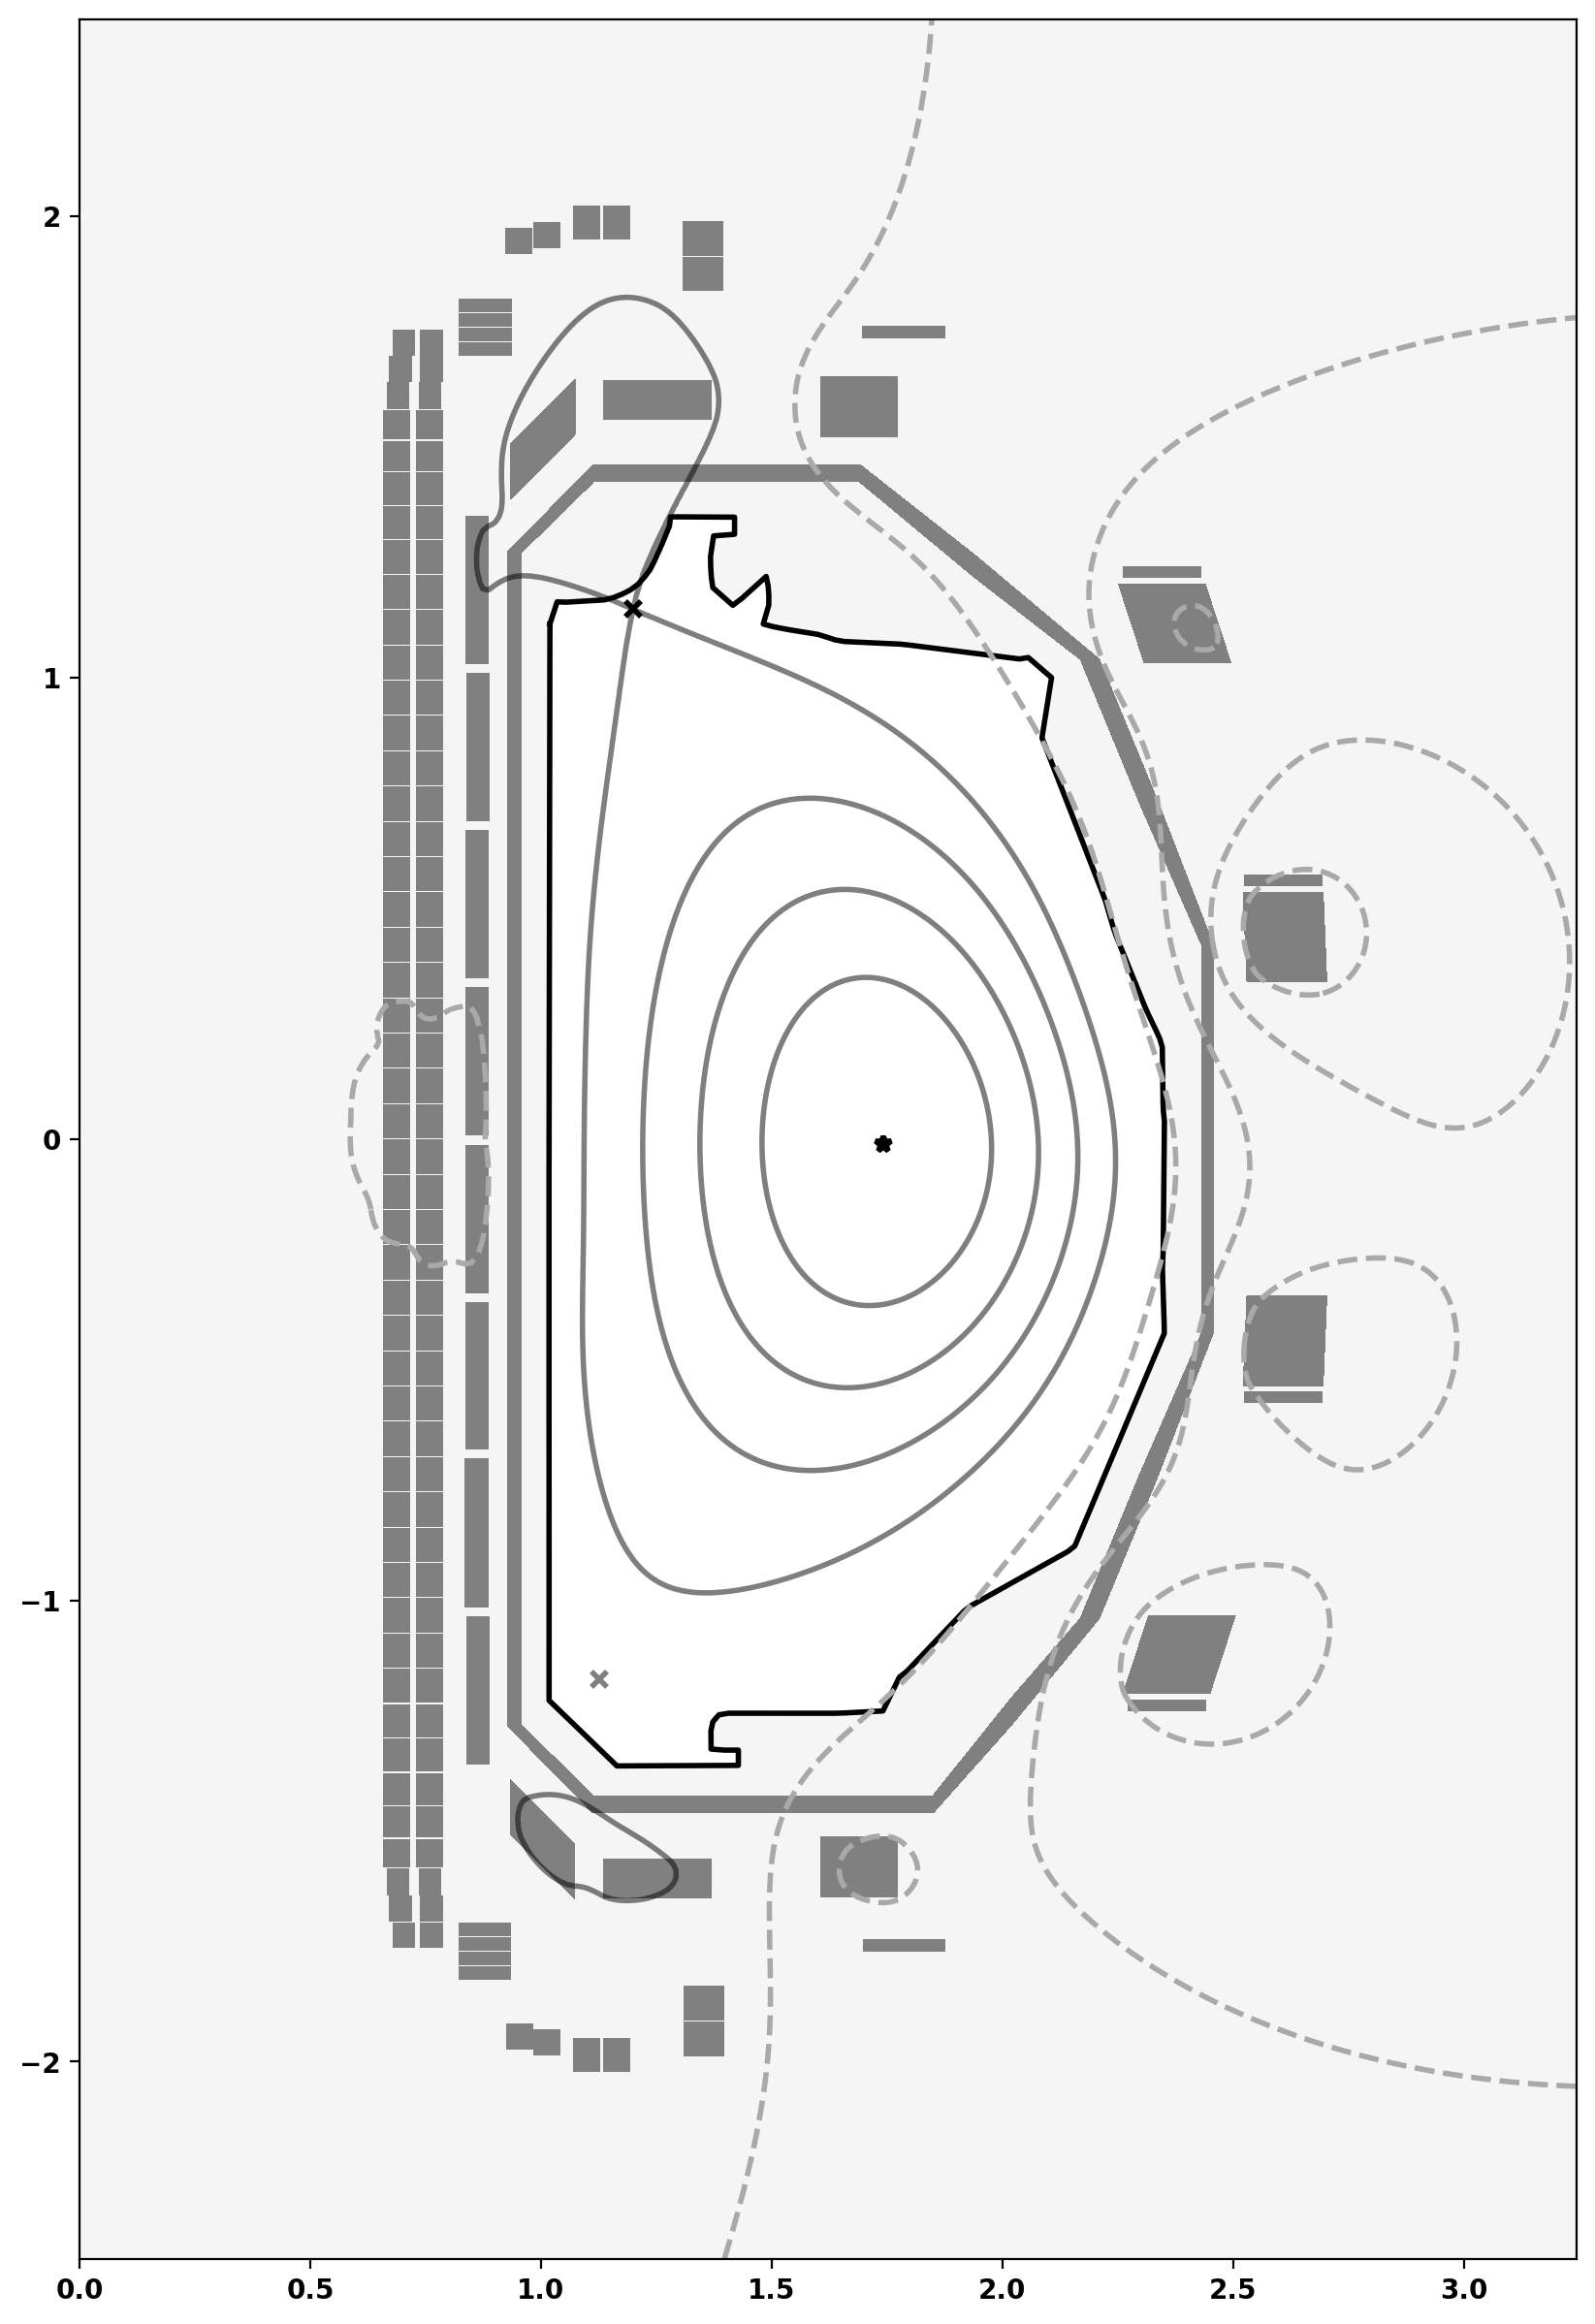

In [27]:
from matplotlib.colors import ListedColormap

fig, ax = plt.subplots(1,1, figsize=(15,15))
cmap = ListedColormap([[0.0, 0.0, 0.0, 0.5]])

mygs.plot_machine(fig,ax,coil_clabel=None)
mygs.plot_psi(fig,ax,plasma_nlevels=5,vacuum_nlevels=5, plasma_colormap=cmap)
mygs.plot_current_density(fig, ax)

# Show the plot
plt.show()

## Plot Current Density in Divertor Region

Starting CG solver
     0  0.000000E+00  0.000000E+00  6.593023E-01
     1 -2.277026E+03  1.134139E+04  8.049686E-02  7.097616E-06
     2 -2.430294E+03  1.362064E+04  3.349801E-02  2.459357E-06
     3 -2.441142E+03  1.383788E+04  9.268277E-03  6.697757E-07
     4 -2.442255E+03  1.385692E+04  3.658036E-03  2.639861E-07
     5 -2.442422E+03  1.383919E+04  1.591337E-03  1.149878E-07
     6 -2.442454E+03  1.383979E+04  5.646354E-04  4.079798E-08
     7 -2.442458E+03  1.383911E+04  1.949865E-04  1.408952E-08
     8 -2.442458E+03  1.383913E+04  7.053168E-05  5.096540E-09
     9 -2.442458E+03  1.383921E+04  3.011673E-05  2.176189E-09
    10 -2.442458E+03  1.383924E+04  1.283758E-05  9.276213E-10
    20 -2.442458E+03  1.383926E+04  7.839632E-10  5.664778E-14


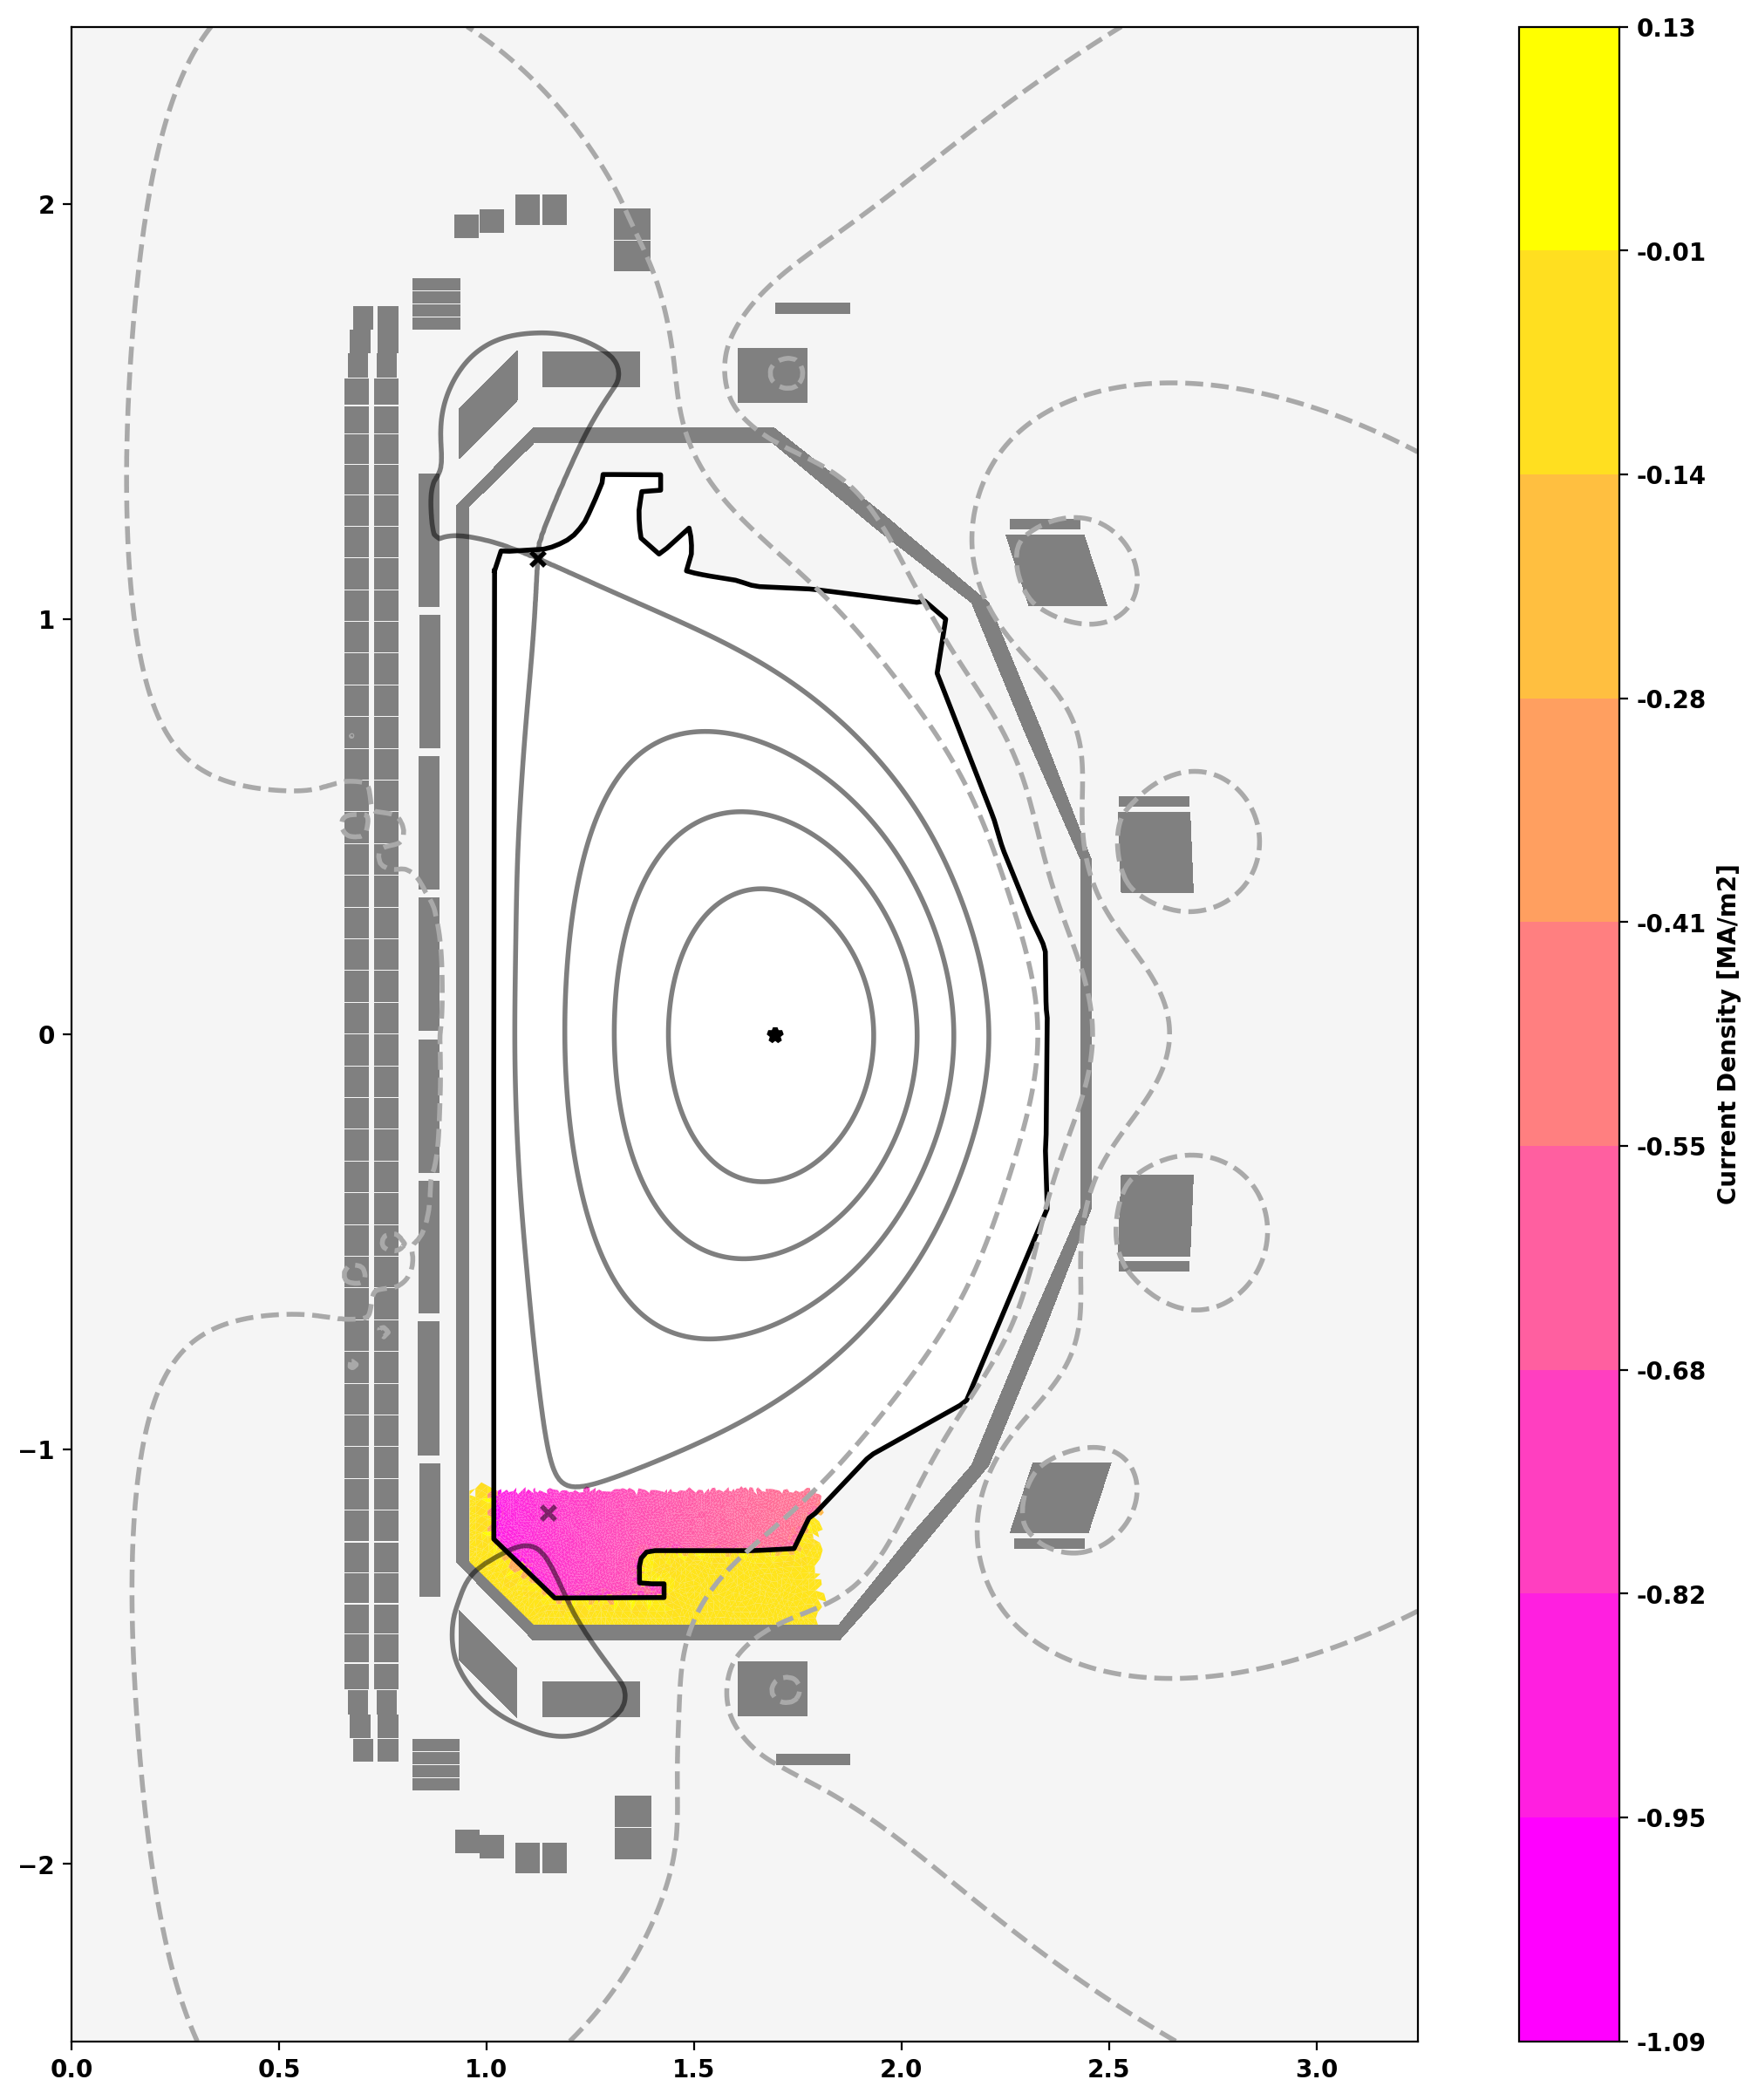

In [ ]:
from matplotlib.colors import ListedColormap

fig, ax = plt.subplots(1,1, figsize=(15,15))
cmap = ListedColormap([[0.0, 0.0, 0.0, 0.5]])

mygs.plot_machine(fig,ax,coil_clabel=None)
mygs.plot_psi(fig,ax,plasma_nlevels=5,vacuum_nlevels=5, plasma_colormap=cmap)
mygs.plot_current_density(fig, ax, window=[0.8, 1.8, -2.0, -1.1])

# Show the plot
plt.show()

## Plot Currents

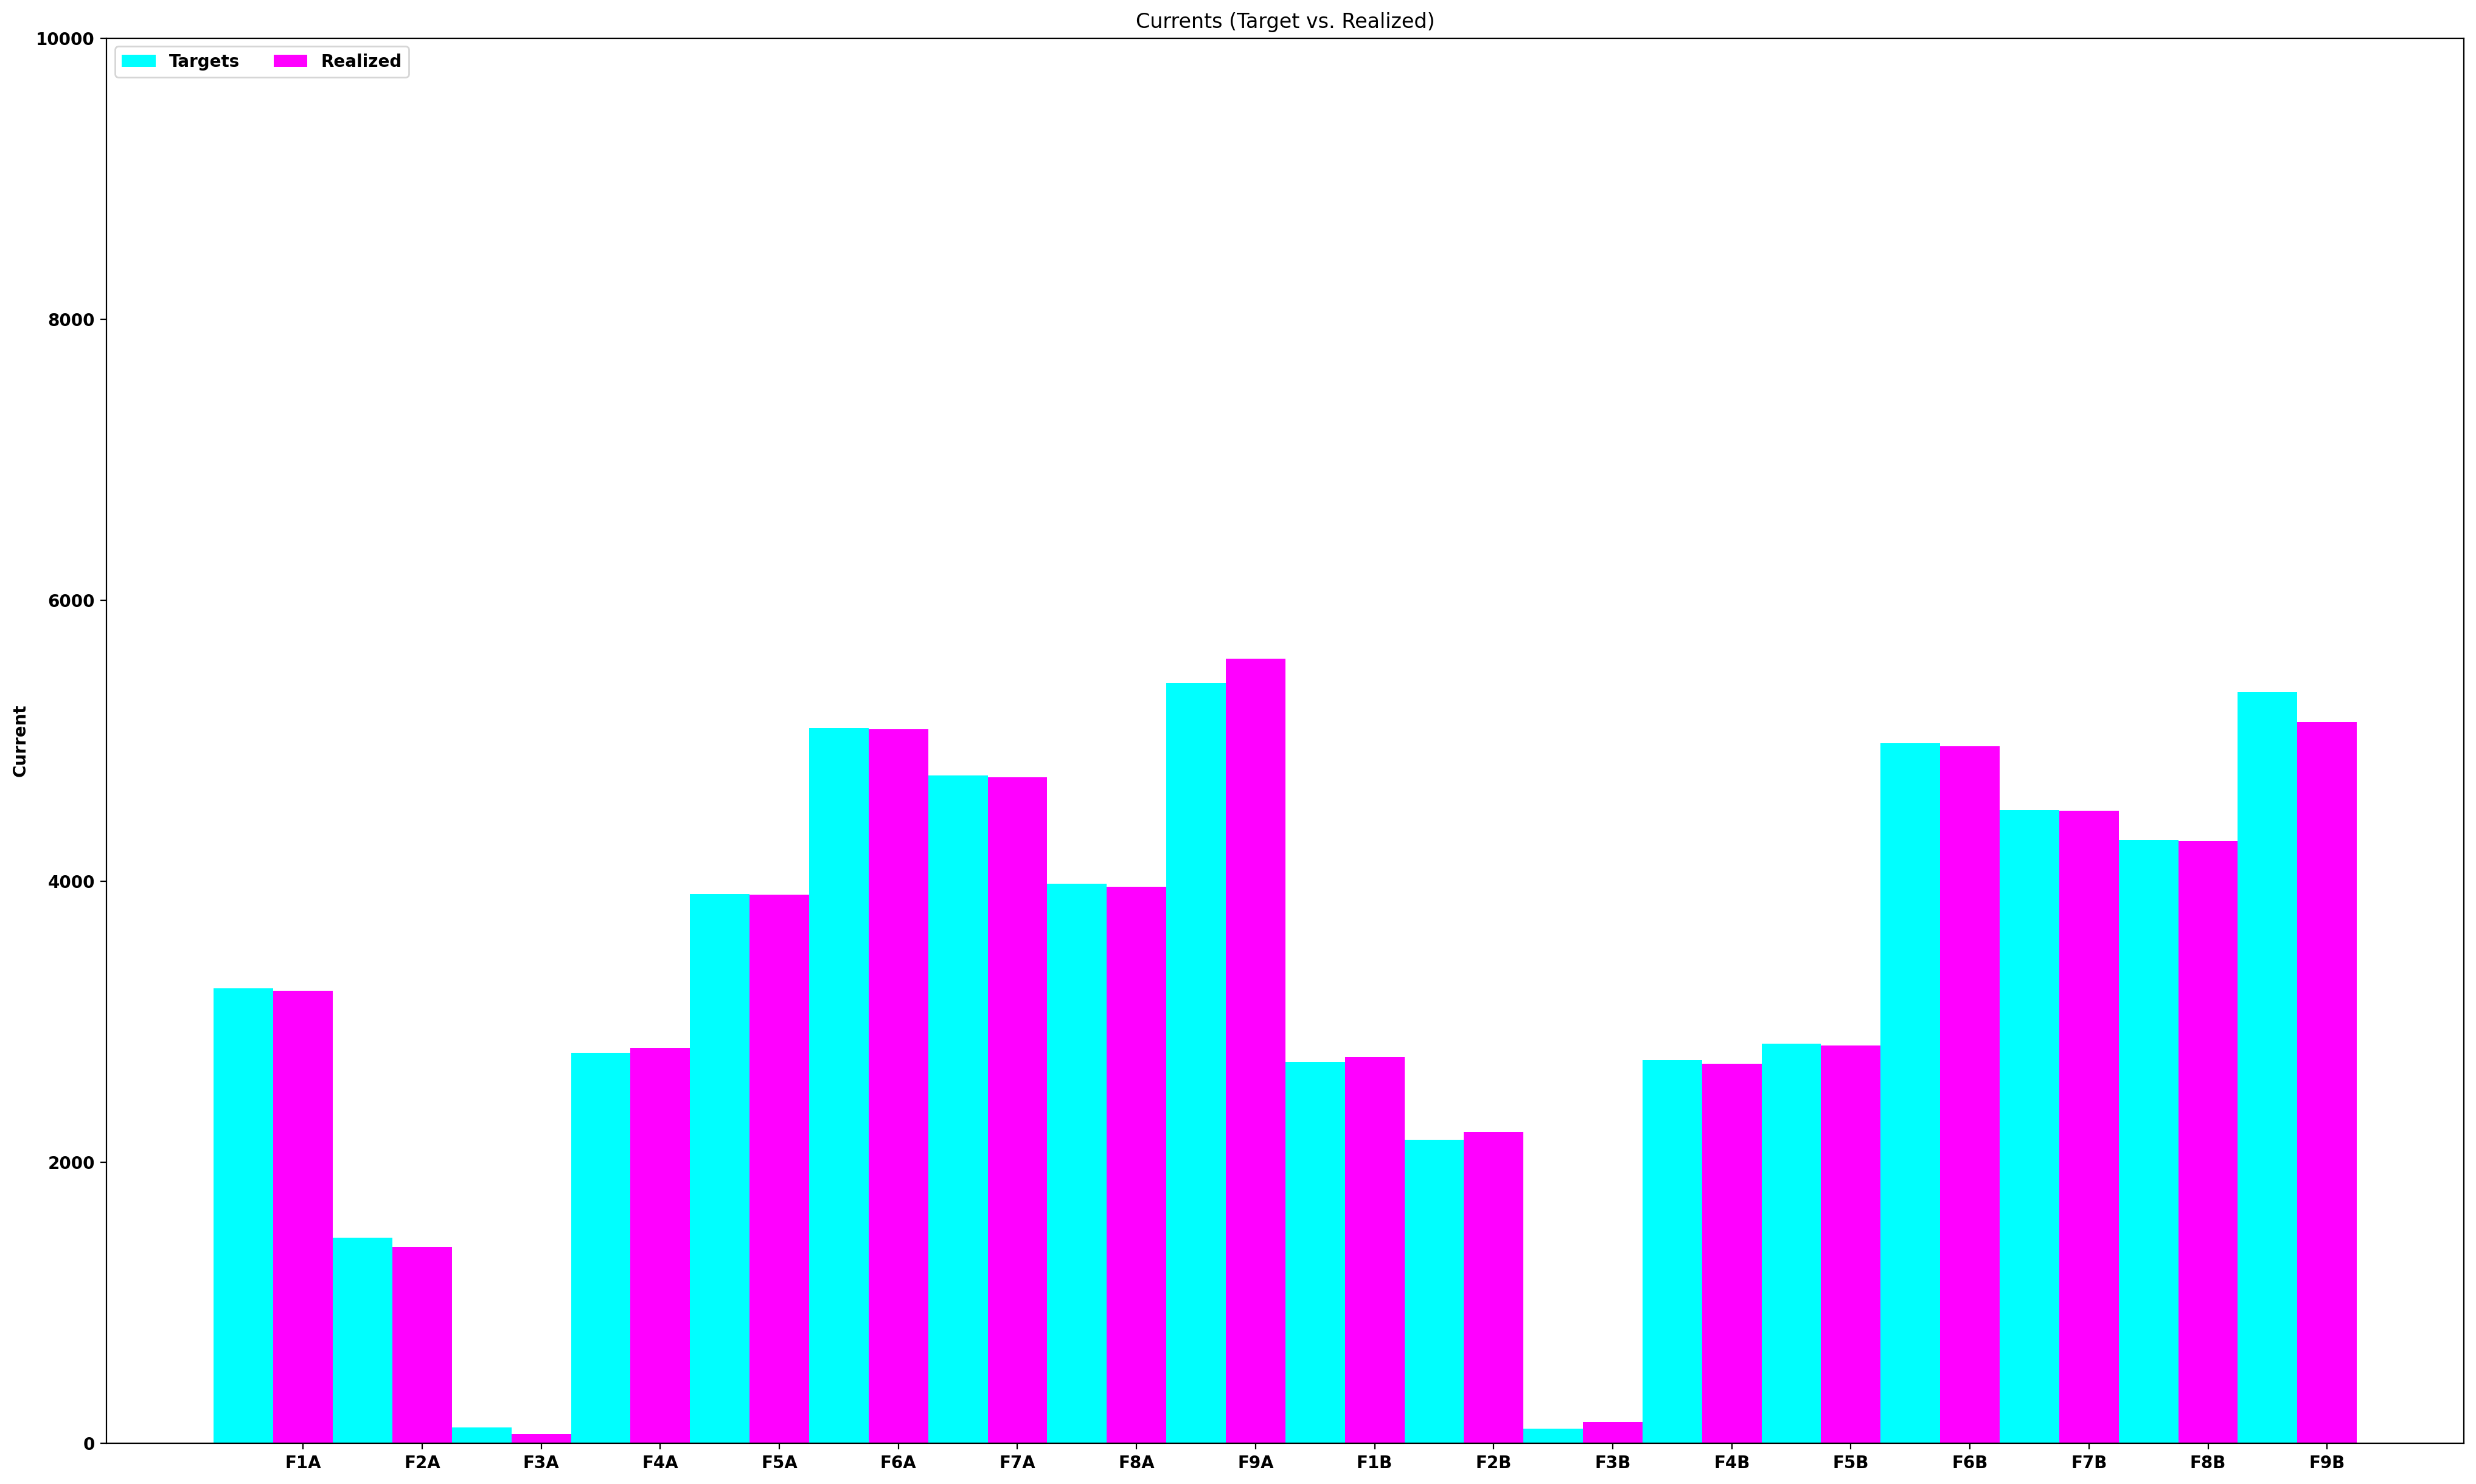

In [ ]:
plot_currents()

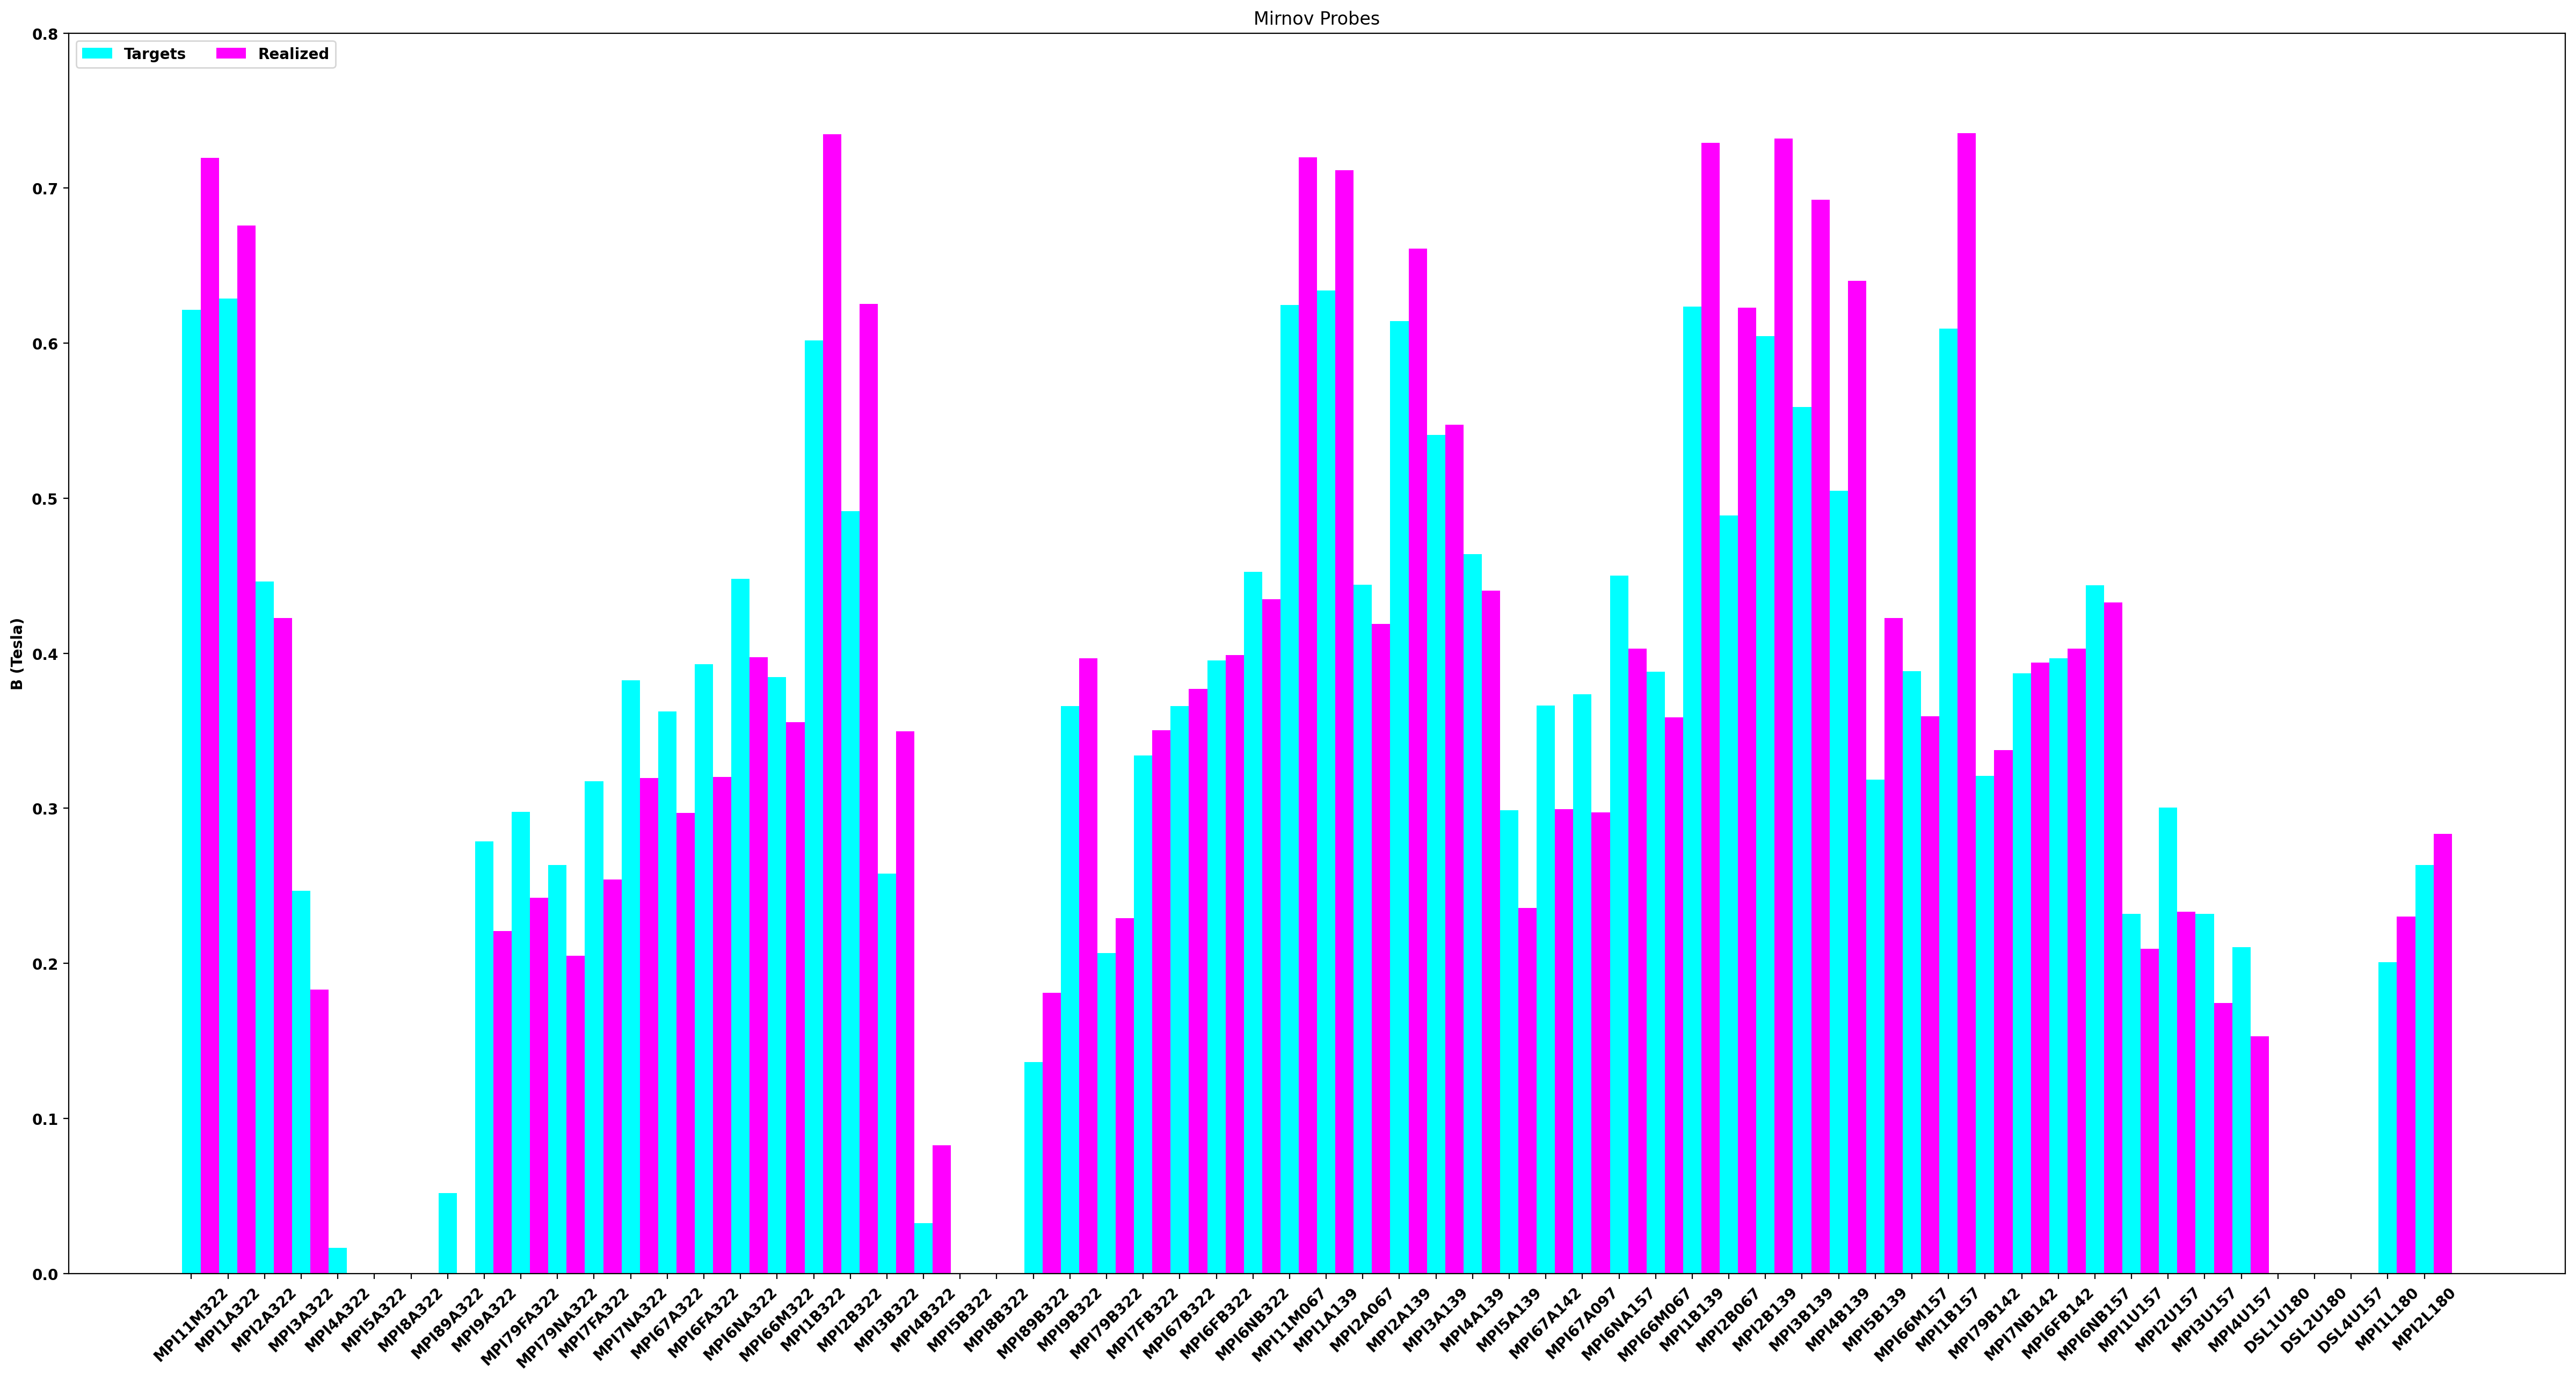

In [ ]:
plot_mirnov()

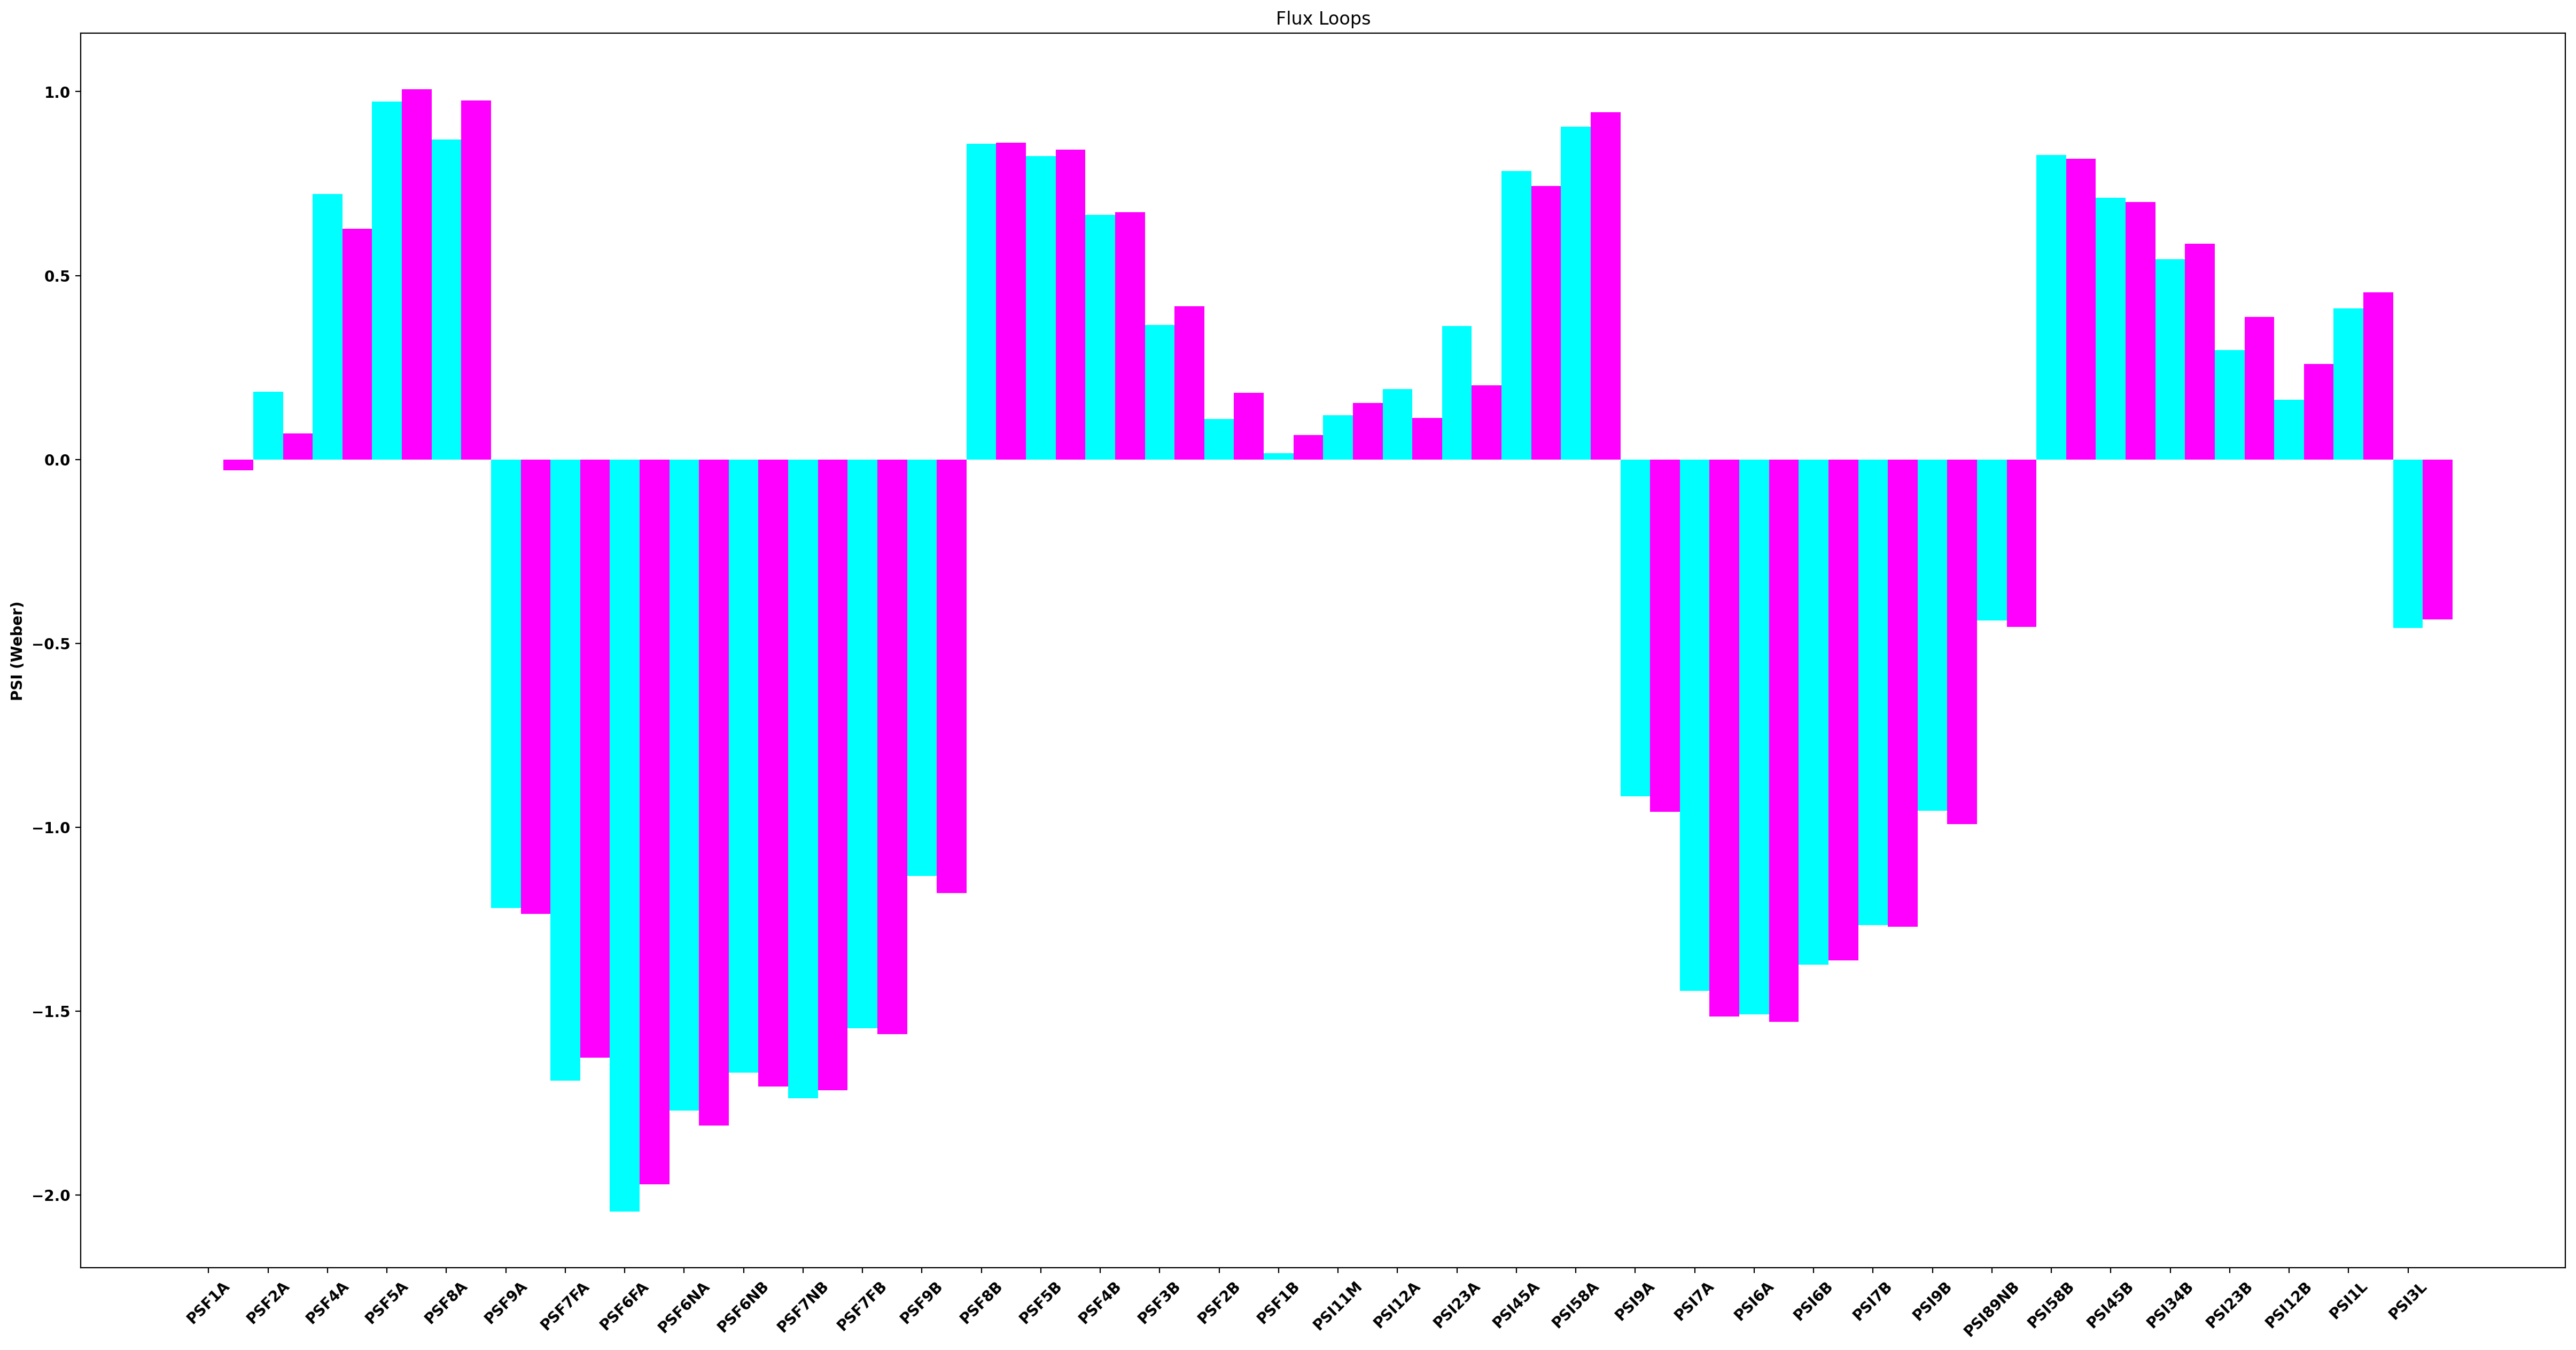

In [ ]:
plot_flux()

## Get Strike Points

In [ ]:
strike_pts = mygs.get_strike_points()

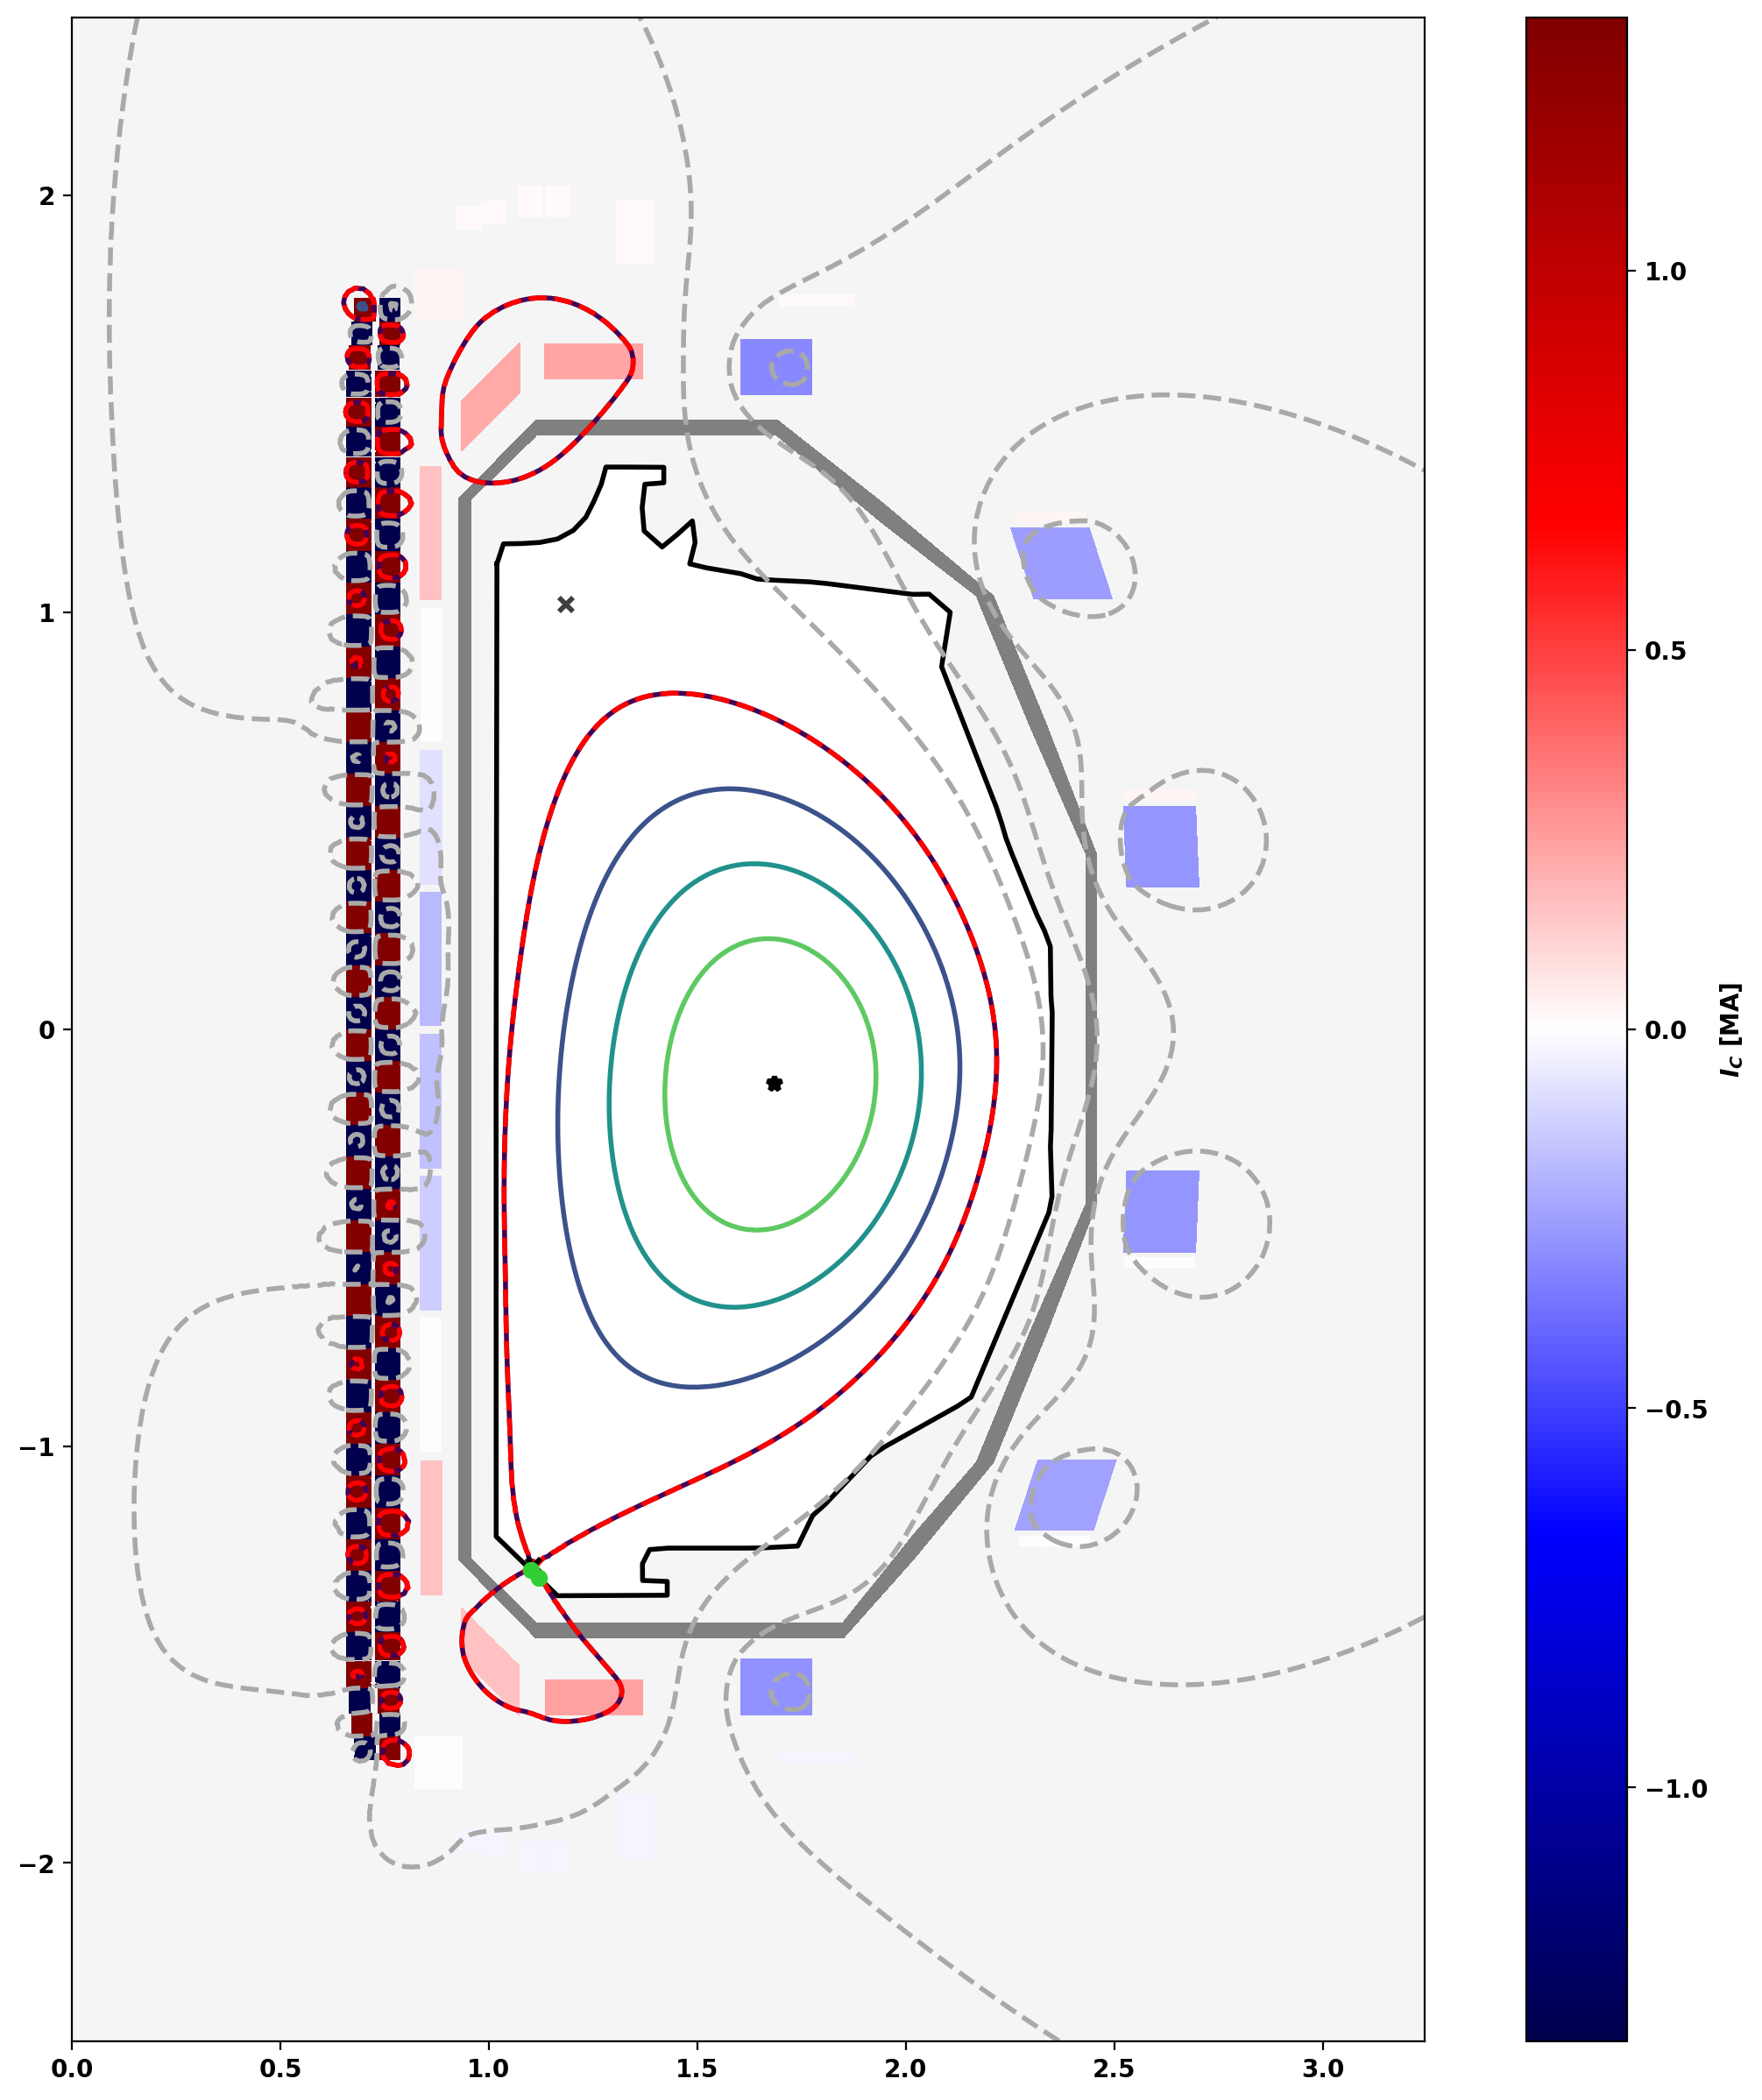

In [ ]:
# Plot Psi
fig, ax = plt.subplots(1,1, figsize=(15,15))
mygs.plot_machine(fig,ax,coil_colormap='seismic',coil_scale=1.E-6,coil_clabel=r'$I_C$ [MA]',coil_symmap=True)
mygs.plot_psi(fig,ax,plasma_nlevels=5,vacuum_nlevels=5)
mygs.plot_psi(fig,ax,psi=psi_eq,plasma_levels=[1.0,],plasma_color='red',vacuum_nlevels=0,plasma_linestyles='dashed')

strike_pts_r = [sp[0] for sp in strike_pts]
strike_pts_z = [sp[1] for sp in strike_pts]
ax.scatter(strike_pts_r, strike_pts_z, color='limegreen', zorder=10)

plt.show()